In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade --force-reinstall numpy torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5

In [ ]:
# =====================================================================
# BLOCK 1: CÀI ĐẶT THƯ VIỆN CẦN THIẾT
# =====================================================================
try:
    import gradio as gr
    import ultralytics
    import cv2
    print("Thư viện Gradio, YOLO, và OpenCV đã được cài đặt.")
except ImportError:
    print("Cài đặt các thư viện cần thiết (gradio, ultralytics, opencv)...")
    !pip install gradio ultralytics opencv-python -q
    print("✅ Cài đặt hoàn tất. Vui lòng CHẠY LẠI CELL NÀY (Runtime -> Restart session, sau đó chạy lại cell này).")
    import sys
    sys.exit()

import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18
from ultralytics import YOLO
import requests
from io import BytesIO
from collections import Counter

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# PHẦN 1: CẤU HÌNH VÀ ĐỊNH NGHĨA CÁC HÀM
# ---------------------------------------------------------------------

# ---------- Paths and Configuration ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(output_dir, exist_ok=True)

MODEL_FRONT_PLATES = "best_model_optimized_front.pth"
MODEL_ROBUST = "best_model_FINAL_robust_v2.pth"

print("\n" + "="*70)
print(f"🔍 CRNN LP RECOGNITION (WEB DEMO - 2 MÔ HÌNH - KHÔNG LM)")
print("="*70 + "\n")

# ---------- CRNN Model Definition (Dropout=0.5) ----------
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        conv = self.cnn_backbone(x); conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1: conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv); output = self.fc(rnn_out)
        output = output.permute(1, 0, 2); output = F.log_softmax(output, dim=2)
        return output

# ---------- CTC Greedy Decode (Duy nhất) ----------
def ctc_greedy_decode(log_probs, idx_to_char_map):
    _, preds = torch.max(log_probs, dim=2); preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []; prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                if p in idx_to_char_map: chars.append(idx_to_char_map[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# ---------------------------------------------------------------------
# PHẦN 2: TẢI TẤT CẢ MÔ HÌNH (YOLO, 2x CRNN)
# ---------------------------------------------------------------------
# (Chúng ta bọc phần tải mô hình trong một hàm để chạy 1 lần)

def load_all_models():
    # Tải Mô hình 1 (Chuyên gia Ảnh Thẳng)
    try:
        model_path_front = os.path.join(output_dir, MODEL_FRONT_PLATES)
        checkpoint_front = torch.load(model_path_front, map_location=device)
        num_classes_saved = len(checkpoint_front['idx_to_char'])

        inference_model_front = CRNN(num_classes=num_classes_saved, hidden_size=256).to(device)
        inference_model_front.load_state_dict(checkpoint_front['model_state_dict'])
        inference_model_front.eval()

        idx_to_char = checkpoint_front['idx_to_char']

        print(f"✅ Mô hình CRNN (FRONT) '{MODEL_FRONT_PLATES}' đã tải thành công.")
    except Exception as e:
        print(f"\n❌ LỖI TẢI MÔ HÌNH FRONT: {e}"); sys.exit()

    # Tải Mô hình 2 (Chuyên gia Ảnh Nghiêng/Robust V2)
    try:
        model_path_robust = os.path.join(output_dir, MODEL_ROBUST)
        checkpoint_robust = torch.load(model_path_robust, map_location=device)

        inference_model_robust = CRNN(num_classes=len(checkpoint_robust['idx_to_char']), hidden_size=256).to(device)
        inference_model_robust.load_state_dict(checkpoint_robust['model_state_dict'])
        inference_model_robust.eval()

        print(f"✅ Mô hình CRNN (ROBUST V2) '{MODEL_ROBUST}' đã tải thành công.")
    except Exception as e:
        print(f"\n❌ LỖI TẢI MÔ HÌNH ROBUST: {e}"); sys.exit()

    # Tải Mô hình YOLO
    yolo_model = None; LP_CLASS_ID = 0
    try:
        YOLO_LP_MODEL_PATH = "/content/drive/MyDrive/DatasetBX/license_plate_detector.pt"
        yolo_model = YOLO(YOLO_LP_MODEL_PATH)
        print(f"✅ Tải mô hình YOLO LP từ {YOLO_LP_MODEL_PATH} thành công.")
    except Exception as e:
        print(f"❌ Lỗi tải YOLO LP: {e}")

    return inference_model_front, inference_model_robust, yolo_model, idx_to_char, LP_CLASS_ID

# Tải tất cả mô hình (chỉ chạy 1 lần)
inference_model_front, inference_model_robust, yolo_model, idx_to_char, LP_CLASS_ID = load_all_models()

# ---------------------------------------------------------------------
# PHẦN 3: ĐỊNH NGHĨA CÁC HÀM PIPELINE (WARP + TTA)
# ---------------------------------------------------------------------

# HÀM NÂNG CẤP: PHÁT HIỆN (YOLO) -> CẮT (CROP) -> LÀM PHẲNG (WARP)
def detect_and_crop_plate_real(pil_image, yolo_model, lp_class_id):
    if yolo_model is None: return None, "Mô hình YOLO LP chưa được tải.", False
    try:
        results = yolo_model(pil_image, verbose=False) # YOLO nhận PIL image
        best_box, best_conf = None, -1
        for r in results:
            if len(r.boxes.xyxy) > 0:
                for box in r.boxes:
                    if int(box.cls.item()) == lp_class_id:
                        conf = box.conf.item()
                        if conf > best_conf: best_box = box.xyxy[0].cpu().numpy().astype(int); best_conf = conf
        if best_box is None:
            if lp_class_id == 0: return detect_and_crop_plate_real(pil_image, yolo_model, 1)
            return None, "KHÔNG TÌM THẤY BIỂN SỐ", False
        x_min, y_min, x_max, y_max = best_box
        cropped_plate_pil = pil_image.crop((x_min, y_min, x_max, y_max))
        cropped_cv2 = cv2.cvtColor(np.array(cropped_plate_pil), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cropped_cv2, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return cropped_plate_pil, f"Phát hiện (Không làm phẳng) (Conf: {best_conf:.2f})", False
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        largest_contour = contours[0]
        epsilon = 0.02 * cv2.arcLength(largest_contour, True)
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if approx.shape[0] == 4: # TÌM THẤY 4 GÓC
            points = approx.reshape(4, 2)
            rect = np.zeros((4, 2), dtype="float32")
            s = points.sum(axis=1); rect[0] = points[np.argmin(s)]; rect[2] = points[np.argmax(s)]
            diff = np.diff(points, axis=1); rect[1] = points[np.argmin(diff)]; rect[3] = points[np.argmax(diff)]
            dst = np.array([[0, 0], [512 - 1, 0], [512 - 1, 128 - 1], [0, 128 - 1]], dtype="float32")
            M = cv2.getPerspectiveTransform(rect, dst)
            warped_cv2 = cv2.warpPerspective(cropped_cv2, M, (512, 128))
            warped_pil = Image.fromarray(cv2.cvtColor(warped_cv2, cv2.COLOR_BGR2RGB))
            return warped_pil, f"Phát hiện (ĐÃ LÀM PHẲNG) (Conf: {best_conf:.2f})", True
        else:
            return cropped_plate_pil, f"Phát hiện (Không làm phẳng) (Conf: {best_conf:.2f})", False
    except Exception as e:
        return None, f"LỖI HỆ THỐNG TRONG DETECTION/WARP: {e}", False

# HÀM TTA (SỬ DỤNG GREEDY DECODE)
def get_tta_transforms(num_augmentations=7):
    base_transform = transforms.Compose([transforms.Resize((128, 512)), transforms.ToTensor()])
    tta_transforms_list = [base_transform]
    for i in range(num_augmentations - 1):
        if i % 3 == 0: aug = [transforms.Resize((128, 512)), transforms.ColorJitter(brightness=0.15, contrast=0.15), transforms.ToTensor()]
        elif i % 3 == 1: aug = [transforms.Resize((128, 512)), transforms.RandomAffine(degrees=3, translate=(0.03, 0.03)), transforms.ToTensor()]
        else: aug = [transforms.Resize((128, 512)), transforms.ColorJitter(brightness=0.1, contrast=0.1), transforms.RandomAffine(degrees=2, translate=(0.02, 0.02)), transforms.ToTensor()]
        tta_transforms_list.append(transforms.Compose(aug))
    return tta_transforms_list

def predict_with_tta(cropped_plate_image, crnn_model, idx_to_char_map, device, num_augmentations=7, verbose=False):
    crnn_model.eval()
    tta_transforms = get_tta_transforms(num_augmentations)
    all_predictions = []
    with torch.no_grad():
        for i, transform in enumerate(tta_transforms):
            try:
                image_tensor = transform(cropped_plate_image).unsqueeze(0).to(device)
                outputs = crnn_model(image_tensor)
                pred_text = ctc_greedy_decode(outputs.cpu(), idx_to_char_map)[0]
                all_predictions.append(pred_text)
            except Exception as e:
                pass # Bỏ qua lỗi TTA
    if not all_predictions: return "", [], 0.0
    counter = Counter(all_predictions); most_common = counter.most_common(1)[0]
    final_prediction, vote_count = most_common[0], most_common[1]
    confidence = vote_count / len(all_predictions)
    return final_prediction, all_predictions, confidence

# HÀM DỰ ĐOÁN HOÀN CHỈNH (CHỌN 2 MÔ HÌNH)
def predict_full_image_pipeline_with_tta(
    full_image_path_or_pil,
    yolo_detector,
    crnn_model_front,
    crnn_model_robust,
    idx_to_char_map,
    device,
    use_tta=True,
    num_augmentations=15,
    verbose_tta=False
):
    result = {'prediction': '', 'confidence': 0.0, 'detection_status': '', 'all_predictions': [], 'success': False}

    # GIAI ĐOẠN 1: YOLO Detection + OpenCV Warp
    cropped_plate_image, detection_status, was_warped = detect_and_crop_plate_real(
        full_image_path_or_pil, yolo_detector, LP_CLASS_ID
    )
    result['detection_status'] = detection_status
    if cropped_plate_image is None:
        print(f"❌ {detection_status}"); return result, None
    print(f"✅ {detection_status}")

    # LOGIC CHỌN MÔ HÌNH
    active_crnn_model = None
    if was_warped:
        print("...Sử dụng mô hình ROBUST V2 (chuyên gia ảnh nghiêng)...")
        active_crnn_model = crnn_model_robust
    else:
        print("...SSử dụng mô hình FRONT (chuyên gia ảnh thẳng)...")
        active_crnn_model = crnn_model_front

    # GIAI ĐOẠN 2: CRNN Recognition
    try:
        if use_tta:
            final_pred, all_preds, confidence = predict_with_tta(
                cropped_plate_image=cropped_plate_image, crnn_model=active_crnn_model,
                idx_to_char_map=idx_to_char_map, device=device,
                num_augmentations=num_augmentations, verbose=verbose_tta
            )
            result.update({'prediction': final_pred, 'confidence': confidence, 'all_predictions': all_preds, 'success': True})

        else:
            val_transform_inference = transforms.Compose([transforms.Resize((128, 512)), transforms.ToTensor()])
            image_tensor = val_transform_inference(cropped_plate_image).unsqueeze(0).to(device)
            with torch.no_grad(): outputs = active_crnn_model(image_tensor)
            predicted_text = ctc_greedy_decode(outputs.cpu(), idx_to_char_map)[0]
            result.update({'prediction': predicted_text, 'confidence': 1.0, 'success': True})

    except Exception as e:
        result['detection_status'] = f"❌ Lỗi CRNN: {e}"
        print(f"❌ Lỗi trong CRNN Recognition: {e}")

    return result, cropped_plate_image # Trả về ảnh đã cắt

# =====================================================================
# BLOCK 4: HÀM CHỨC NĂNG CHÍNH CỦA WEB (DÙNG GRADIO)
# =====================================================================

def predict_license_plate_web(input_image_pil):
    """
    Hàm này sẽ được Gradio gọi.
    """
    if input_image_pil is None:
        return None, "Vui lòng tải ảnh lên."

    # Gọi hàm pipeline chính
    result, output_image = predict_full_image_pipeline_with_tta(
        full_image_path_or_pil=input_image_pil,
        yolo_detector=yolo_model,
        crnn_model_front=inference_model_front,
        crnn_model_robust=inference_model_robust,
        idx_to_char_map=idx_to_char,
        device=device,
        use_tta=True,
        num_augmentations=15,
        verbose_tta=False
    )

    # Format text đầu ra
    if result['success']:
        output_text = f"Kết quả: {result['prediction']}\nConfidence: {result['confidence']:.1%}\nTrạng thái: {result['detection_status']}"
    else:
        output_text = f"Lỗi: {result['detection_status']}"

    return output_image, output_text

# =====================================================================
# BLOCK 5: KHỞI CHẠY GIAO DIỆN WEB
# =====================================================================

print("\n" + "="*70)
print("🚀 KHỞI CHẠY GIAO DIỆN WEB DEMO (Không có LM)...")
print("="*70)

# Định nghĩa giao diện
# Sử dụng gr.Blocks() để tùy chỉnh linh hoạt hơn
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # Trình Nhận dạng Biển số Xe (YOLO + OpenCV Warp + 2 CRNNs)
        Tải lên ảnh xe hơi (thẳng hoặc nghiêng). Hệ thống sẽ tự động phát hiện, làm phẳng (nếu cần),
        và chọn mô hình CRNN phù hợp để nhận dạng.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Tải ảnh xe hơi của bạn")
            submit_button = gr.Button("Nhận dạng", variant="primary")

            gr.Examples(
                examples=[
                    "/content/drive/MyDrive/DatasetBX/24.jpg",
                    "/content/drive/MyDrive/DatasetBX/26.jpg",
                    "/content/drive/MyDrive/DatasetBX/30G63223.jpg"
                ],
                inputs=input_image
            )

        with gr.Column(scale=1):
            output_image = gr.Image(type="pil", label="Ảnh biển số (Đã cắt và làm phẳng nếu cần)")

            # ⚠️ NÂNG CẤP: LÀM KHUNG TEXTBOX TO HƠN (lines=4)
            output_text = gr.Textbox(label="Kết quả Nhận dạng (CRNN + TTA)", lines=4)

    # Xử lý sự kiện click
    submit_button.click(
        fn=predict_license_plate_web,
        inputs=input_image,
        outputs=[output_image, output_text]
    )

# Chạy giao diện
# share=True để tạo link public
# auth=("user", "password") # Tùy chọn: Thêm mật khẩu
try:
    demo.launch(share=True, debug=True)
except Exception as e:
    print(f"Lỗi khi khởi chạy Gradio: {e}")
    print("Đang thử khởi chạy lại mà không có debug...")
    demo.launch(share=True) # Thử chạy lại

# ⚠️ NÂNG CẤP: NÚT DỪNG
print("\n" + "="*70)
print("Giao diện Gradio đang chạy. Nhấn vào link public ở trên.")
print("Khi bạn muốn DỪNG (STOP) server, hãy nhấn nút 'Stop' (Hình vuông) trên thanh công cụ của Colab.")
print("Hoặc bạn có thể chạy cell tiếp theo với lệnh 'demo.close()'")
print("="*70)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Thư viện Gradio, YOLO, và OpenCV đã được cài đặt.

🔍 CRNN LP RECOGNITION (WEB DEMO - 2 MÔ HÌNH - KHÔNG LM)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


✅ Mô hình CRNN (FRONT) 'best_model_optimized_front.pth' đã tải thành công.
✅ Mô hình CRNN (ROBUST V2) 'best_model_FINAL_robust_v2.pth' đã tải thành công.
✅ Tải mô hình YOLO LP từ /content/drive/MyDrive/DatasetBX/license_plate_detector.pt thành công.

🚀 KHỞI CHẠY GIAO DIỆN WEB DEMO (Không có LM)...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://05b51d635c63d36e1d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Phát hiện (ĐÃ LÀM PHẲNG) (Conf: 0.61)
...Sử dụng mô hình ROBUST V2 (chuyên gia ảnh nghiêng)...
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://05b51d635c63d36e1d.gradio.live

Giao diện Gradio đang chạy. Nhấn vào link public ở trên.
Khi bạn muốn DỪNG (STOP) server, hãy nhấn nút 'Stop' (Hình vuông) trên thanh công cụ của Colab.
Hoặc bạn có thể chạy cell tiếp theo với lệnh 'demo.close()'


In [ ]:
# =====================================================================
# BLOCK 6: CELL ĐỂ DỪNG (STOP) WEB DEMO
# =====================================================================
# Chạy cell này khi bạn muốn tắt giao diện web
try:
    demo.close()
    print("✅ Đã đóng giao diện Gradio.")
except NameError:
    print("⚠️ Giao diện 'demo' chưa được khởi chạy.")
except Exception as e:
    print(f"Lỗi khi đóng giao diện: {e}")

Closing server running on port: 7860
✅ Đã đóng giao diện Gradio.


1 ảnh chứa nhiều xe và test

In [3]:
# =====================================================================
# BLOCK 1: CÀI ĐẶT THƯ VIỆN CẦN THIẾT
# =====================================================================
try:
    import gradio as gr
    import ultralytics
    import cv2
    print("Thư viện Gradio, YOLO, và OpenCV đã được cài đặt.")
except ImportError:
    print("Cài đặt các thư viện cần thiết (gradio, ultralytics, opencv)...")
    !pip install gradio ultralytics opencv-python -q
    print("✅ Cài đặt hoàn tất. Vui lòng CHẠY LẠI CELL NÀY (Runtime -> Restart session, sau đó chạy lại cell này).")
    import sys
    sys.exit()

import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18
from ultralytics import YOLO
import requests
from io import BytesIO
from collections import Counter

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# PHẦN 1: CẤU HÌNH VÀ ĐỊNH NGHĨA CÁC HÀM
# ---------------------------------------------------------------------

# ---------- Paths and Configuration ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(output_dir, exist_ok=True)

MODEL_FRONT_PLATES = "best_model_optimized_front.pth"
MODEL_ROBUST = "best_model_FINAL_robust_v2.pth"

print("\n" + "="*70)
print(f"🔍 CRNN LP RECOGNITION (WEB DEMO - XỬ LÝ NHIỀU BIỂN SỐ)")
print("="*70 + "\n")

# ---------- CRNN Model Definition (Dropout=0.5) ----------
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        conv = self.cnn_backbone(x); conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1: conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv); output = self.fc(rnn_out)
        output = output.permute(1, 0, 2); output = F.log_softmax(output, dim=2)
        return output

# ---------- CTC Greedy Decode (Duy nhất) ----------
def ctc_greedy_decode(log_probs, idx_to_char_map):
    _, preds = torch.max(log_probs, dim=2); preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []; prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                if p in idx_to_char_map: chars.append(idx_to_char_map[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# ---------------------------------------------------------------------
# PHẦN 2: TẢI TẤT CẢ MÔ HÌNH (YOLO, 2x CRNN)
# ---------------------------------------------------------------------

def load_all_models():
    try:
        model_path_front = os.path.join(output_dir, MODEL_FRONT_PLATES)
        checkpoint_front = torch.load(model_path_front, map_location=device)
        inference_model_front = CRNN(num_classes=len(checkpoint_front['idx_to_char']), hidden_size=256).to(device)
        inference_model_front.load_state_dict(checkpoint_front['model_state_dict'])
        inference_model_front.eval()
        idx_to_char = checkpoint_front['idx_to_char']
        print(f"✅ Mô hình CRNN (FRONT) '{MODEL_FRONT_PLATES}' đã tải thành công.")
    except Exception as e:
        print(f"\n❌ LỖI TẢI MÔ HÌNH FRONT: {e}"); sys.exit()

    try:
        model_path_robust = os.path.join(output_dir, MODEL_ROBUST)
        checkpoint_robust = torch.load(model_path_robust, map_location=device)
        inference_model_robust = CRNN(num_classes=len(checkpoint_robust['idx_to_char']), hidden_size=256).to(device)
        inference_model_robust.load_state_dict(checkpoint_robust['model_state_dict'])
        inference_model_robust.eval()
        print(f"✅ Mô hình CRNN (ROBUST V2) '{MODEL_ROBUST}' đã tải thành công.")
    except Exception as e:
        print(f"\n❌ LỖI TẢI MÔ HÌNH ROBUST: {e}"); sys.exit()

    yolo_model = None; LP_CLASS_ID = 0
    try:
        YOLO_LP_MODEL_PATH = "/content/drive/MyDrive/DatasetBX/license_plate_detector.pt"
        yolo_model = YOLO(YOLO_LP_MODEL_PATH)
        print(f"✅ Tải mô hình YOLO LP từ {YOLO_LP_MODEL_PATH} thành công.")
    except Exception as e:
        print(f"❌ Lỗi tải YOLO LP: {e}")

    return inference_model_front, inference_model_robust, yolo_model, idx_to_char, LP_CLASS_ID

inference_model_front, inference_model_robust, yolo_model, idx_to_char, LP_CLASS_ID = load_all_models()

# ---------------------------------------------------------------------
# PHẦN 3: ĐỊNH NGHĨA CÁC HÀM PIPELINE (WARP + TTA)
# ---------------------------------------------------------------------

# HÀM LÀM PHẲNG (WARP) - Giờ chỉ xử lý 1 ảnh đã cắt
def warp_plate_image(cropped_plate_pil):
    try:
        cropped_cv2 = cv2.cvtColor(np.array(cropped_plate_pil), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(cropped_cv2, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return cropped_plate_pil, False # Không làm phẳng

        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        largest_contour = contours[0]
        epsilon = 0.02 * cv2.arcLength(largest_contour, True)
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)

        if approx.shape[0] == 4: # TÌM THẤY 4 GÓC
            points = approx.reshape(4, 2)
            rect = np.zeros((4, 2), dtype="float32")
            s = points.sum(axis=1); rect[0] = points[np.argmin(s)]; rect[2] = points[np.argmax(s)]
            diff = np.diff(points, axis=1); rect[1] = points[np.argmin(diff)]; rect[3] = points[np.argmax(diff)]
            dst = np.array([[0, 0], [512 - 1, 0], [512 - 1, 128 - 1], [0, 128 - 1]], dtype="float32")
            M = cv2.getPerspectiveTransform(rect, dst)
            warped_cv2 = cv2.warpPerspective(cropped_cv2, M, (512, 128))
            warped_pil = Image.fromarray(cv2.cvtColor(warped_cv2, cv2.COLOR_BGR2RGB))
            return warped_pil, True # Đã làm phẳng
        else:
            return cropped_plate_pil, False # Không làm phẳng
    except Exception as e:
        print(f"Lỗi OpenCV Warp: {e}")
        return cropped_plate_pil, False

# HÀM TTA (SỬ DỤNG GREEDY DECODE)
def get_tta_transforms(num_augmentations=7):
    base_transform = transforms.Compose([transforms.Resize((128, 512)), transforms.ToTensor()])
    tta_transforms_list = [base_transform]
    for i in range(num_augmentations - 1):
        if i % 3 == 0: aug = [transforms.Resize((128, 512)), transforms.ColorJitter(brightness=0.15, contrast=0.15), transforms.ToTensor()]
        elif i % 3 == 1: aug = [transforms.Resize((128, 512)), transforms.RandomAffine(degrees=3, translate=(0.03, 0.03)), transforms.ToTensor()]
        else: aug = [transforms.Resize((128, 512)), transforms.ColorJitter(brightness=0.1, contrast=0.1), transforms.RandomAffine(degrees=2, translate=(0.02, 0.02)), transforms.ToTensor()]
        tta_transforms_list.append(transforms.Compose(aug))
    return tta_transforms_list

def predict_with_tta(cropped_plate_image, crnn_model, idx_to_char_map, device, num_augmentations=7):
    crnn_model.eval()
    tta_transforms = get_tta_transforms(num_augmentations)
    all_predictions = []
    with torch.no_grad():
        for i, transform in enumerate(tta_transforms):
            try:
                image_tensor = transform(cropped_plate_image).unsqueeze(0).to(device)
                outputs = crnn_model(image_tensor)
                pred_text = ctc_greedy_decode(outputs.cpu(), idx_to_char_map)[0]
                all_predictions.append(pred_text)
            except Exception as e:
                pass
    if not all_predictions: return "", 0.0
    counter = Counter(all_predictions); most_common = counter.most_common(1)[0]
    final_prediction, vote_count = most_common[0], most_common[1]
    confidence = vote_count / len(all_predictions)
    return final_prediction, confidence

# =====================================================================
# BLOCK 4: HÀM CHỨC NĂNG CHÍNH CỦA WEB (XỬ LÝ NHIỀU BIỂN SỐ)
# =====================================================================

def predict_multiple_plates_web(input_image_pil):
    """
    Hàm này sẽ được Gradio gọi.
    Đầu vào: input_image_pil (PIL Image từ web)
    Đầu ra: (List các ảnh đã cắt, string kết quả)
    """
    if input_image_pil is None:
        return None, "Vui lòng tải ảnh lên."

    if yolo_model is None:
        return None, "Lỗi: Mô hình YOLO chưa được tải."

    print(f"\n--- Bắt đầu Xử lý ảnh (Đa biển số) ---")

    # GIAI ĐOẠN 1: YOLO Detection (Tìm TẤT CẢ biển số)
    results = yolo_model(input_image_pil, verbose=False, conf=0.3) # Đặt conf threshold

    processed_images = [] # List để chứa ảnh gallery
    output_texts = []     # List để chứa text kết quả

    if not results or len(results[0].boxes) == 0:
        return None, "KHÔNG TÌM THẤY BIỂN SỐ"

    print(f"✅ Phát hiện được {len(results[0].boxes)} biển số.")

    # LẶP QUA TỪNG BIỂN SỐ ĐƯỢC PHÁT HIỆN
    for i, box in enumerate(results[0].boxes):
        try:
            # 1. Cắt ảnh
            coords = box.xyxy[0].cpu().numpy().astype(int)
            x_min, y_min, x_max, y_max = coords
            cropped_plate_pil = input_image_pil.crop((x_min, y_min, x_max, y_max))

            # 2. Làm phẳng (Warp)
            warped_plate, was_warped = warp_plate_image(cropped_plate_pil)
            processed_images.append(warped_plate) # Thêm ảnh đã xử lý vào gallery

            # 3. Chọn mô hình CRNN
            active_crnn_model = None
            if was_warped:
                active_crnn_model = inference_model_robust
            else:
                active_crnn_model = inference_model_front

            # 4. Nhận dạng (TTA)
            prediction, confidence = predict_with_tta(
                cropped_plate_image=warped_plate,
                crnn_model=active_crnn_model,
                idx_to_char_map=idx_to_char,
                device=device,
                num_augmentations=7 # Giảm TTA để nhanh hơn
            )

            # 5. Thêm kết quả
            text_result = f"Biển số {i+1}: {prediction} (Confidence: {confidence:.1%})"
            output_texts.append(text_result)
            print(f"  > {text_result} | Đã làm phẳng: {was_warped}")

        except Exception as e:
            print(f"Lỗi xử lý biển số {i+1}: {e}")
            output_texts.append(f"Biển số {i+1}: LỖI XỬ LÝ")

    # Trả về List ảnh và String kết quả
    return processed_images, "\n".join(output_texts)

# =====================================================================
# BLOCK 5: KHỞI CHẠY GIAO DIỆN WEB
# =====================================================================

print("\n" + "="*70)
print("🚀 KHỞI CHẠY GIAO DIỆN WEB DEMO (Xử lý nhiều biển số)...")
print("="*70)
import gradio as gr

# 1. Định nghĩa CSS
# Chỉnh font-size to lên (ví dụ 24px), in đậm cho dễ nhìn
custom_css = """
#output_box textarea {
    font-size: 28px !important;
    font-weight: bold !important;
    line-height: 1.5 !important;
}
"""
# Định nghĩa giao diện
with gr.Blocks(theme=gr.themes.Soft(),css=custom_css) as demo:
    gr.Markdown(
        """
        # Trình Nhận dạng Đa Biển số Xe (YOLO + OpenCV Warp + 2 CRNNs)
        Tải lên ảnh xe hơi (có thể chứa nhiều biển số). Hệ thống sẽ phát hiện, làm phẳng (nếu cần),
        và nhận dạng TẤT CẢ các biển số tìm thấy.
        """
    )
    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Tải ảnh xe hơi của bạn")
            submit_button = gr.Button("Nhận dạng", variant="primary")
            gr.Examples(
                examples=[
                    "/content/drive/MyDrive/DatasetBX/24.jpg", # 1 biển
                    "/content/drive/MyDrive/DatasetBX/26.jpg", # 1 biển nghiêng
                    "/content/drive/MyDrive/DatasetBX/30.jpg" # 1 biển G/B
                    # Bạn nên thêm ảnh có nhiều biển số vào đây nếu có
                ],
                inputs=input_image
            )
        with gr.Column(scale=1):
            # ⚠️ NÂNG CẤP: Dùng Gallery để hiển thị nhiều ảnh
            output_gallery = gr.Gallery(label="Các Biển số đã cắt/làm phẳng",
                                        columns=2, object_fit="contain", height="auto")

            # ⚠️ NÂNG CẤP: Textbox to hơn
            output_text = gr.Textbox(label="Kết quả Nhận dạng (CRNN + TTA)", lines=5,elem_id="output_box")

    submit_button.click(
        fn=predict_multiple_plates_web,
        inputs=input_image,
        outputs=[output_gallery, output_text]
    )

# Chạy giao diện
try:
    demo.launch(share=True, debug=True)
except Exception as e:
    print(f"Lỗi khi khởi chạy Gradio: {e}")
    demo.launch(share=True)

print("\n" + "="*70)
print("Giao diện Gradio đang chạy. Nhấn vào link public ở trên.")
print("Khi bạn muốn DỪNG (STOP) server, hãy nhấn nút 'Stop' (Hình vuông) trên thanh công cụ của Colab.")
print("="*70)

# Cell Dừng (Để ở ô riêng)
# try:
#     demo.close()
#     print("✅ Đã đóng giao diện Gradio.")
# except NameError:
#     print("⚠️ Giao diện 'demo' chưa được khởi chạy.")

Thư viện Gradio, YOLO, và OpenCV đã được cài đặt.

🔍 CRNN LP RECOGNITION (WEB DEMO - XỬ LÝ NHIỀU BIỂN SỐ)

✅ Mô hình CRNN (FRONT) 'best_model_optimized_front.pth' đã tải thành công.
✅ Mô hình CRNN (ROBUST V2) 'best_model_FINAL_robust_v2.pth' đã tải thành công.
✅ Tải mô hình YOLO LP từ /content/drive/MyDrive/DatasetBX/license_plate_detector.pt thành công.

🚀 KHỞI CHẠY GIAO DIỆN WEB DEMO (Xử lý nhiều biển số)...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://efc5e2d80d812eeea6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 1 biển số.
  > Biển số 1: 12A14277 (Confidence: 71.4%) | Đã làm phẳng: True

--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 1 biển số.
  > Biển số 1: 30B63223 (Confidence: 57.1%) | Đã làm phẳng: False

--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 1 biển số.
  > Biển số 1: 18A12345 (Confidence: 100.0%) | Đã làm phẳng: False

--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 1 biển số.
  > Biển số 1: 60A99999 (Confidence: 100.0%) | Đã làm phẳng: False

--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 2 biển số.
  > Biển số 1: 511 (Confidence: 100.0%) | Đã làm phẳng: True
  > Biển số 2: 73A12272 (Confidence: 28.6%) | Đã làm phẳng: False

--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 2 biển số.
  > Biển số 1: 11 (Confidence: 28.6%) | Đã làm phẳng: False
  > Biển số 2: 111111 (Confidence: 71.4%) | Đã làm phẳng: False

--- Bắt đầu Xử lý ảnh (Đa biển số) ---
✅ Phát hiện được 1 biển số.
  > Biển

# ---------- Transforms (less aggressive) dạng đã test biển số trước ----------
train_transform = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1), ratio=(0.5, 2.0))
])

val_transform = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
đây là augmentatuion train biển số dạng trước của tôi

In [ ]:
import sys # Import sys at the beginning
import os
try:
    import ultralytics
    print("Thư viện YOLO (ultralytics) đã được cài đặt.")
except ImportError:
    print("Cài đặt các thư viện cần thiết (ultralytics, requests)...")
    !pip install ultralytics requests -q
    print("✅ Cài đặt hoàn tất. Vui lòng chạy lại toàn bộ chương trình (Nếu đang ở Colab, chọn Runtime -> Restart session).")
    sys.exit() # Dừng lại để kernel nhận thư viện mới

import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18
# Thư viện cho YOLO
from ultralytics import YOLO
import requests
from io import BytesIO
from collections import Counter # <-- FIX LỖI NAMEERROR: ĐÃ IMPORT COUNTER

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# PHẦN 1: CẤU HÌNH, TẢI DỮ LIỆU VÀ ĐỊNH NGHĨA CRNN (FIXED)
# ---------------------------------------------------------------------

# ---------- Seed ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ---------- Paths and Configuration ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
os.makedirs(output_dir, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_TO_LOAD = "best_model_new.pth" # <-- Tải mô hình đã train với Robust Augmentation

print("\n" + "="*70)
print("🔍 CRNN LICENSE PLATE RECOGNITION (INFERENCE MODE)")
print("="*70 + "\n")

# ---------- Read labels and Vocabulary (Cần thiết để có char_to_idx) ----------
def read_labels_simple(file_path):
    image_paths, texts = [], []
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) == 2:
                    texts.append(parts[1].replace(" ", "").upper())
    except FileNotFoundError:
        print(f"Warning: File not found at {file_path}. Cannot load vocabulary fully.")
    return texts

train_label_file = os.path.join(base_dir, "train_label_filtered_unique.txt")
val_label_file = os.path.join(base_dir, "valid_label_filtered_unique.txt")
all_texts = read_labels_simple(train_label_file) + read_labels_simple(val_label_file)

all_chars = set(''.join(all_texts))
char_to_idx = {char: idx+1 for idx, char in enumerate(sorted(all_chars))}
char_to_idx['<BLANK>'] = 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

print(f"📚 Vocabulary: Vocab size (with blank): {num_classes}\n")

# ---------- CRNN Model (FIXED) ----------
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()

        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn_backbone(x)
        conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1:
            conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2)
        conv = conv.permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        output = output.permute(1, 0, 2)
        output = F.log_softmax(output, dim=2)
        return output

# Hàm Decode (CTC greedy)
def ctc_greedy_decode(log_probs):
    _, preds = torch.max(log_probs, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                # Đảm bảo idx_to_char có thể truy cập được
                if p in idx_to_char:
                    chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# ---------------------------------------------------------------------
# PHẦN 2: TẢI MÔ HÌNH VÀ THIẾT LẬP HỆ THỐNG 2 GIAI ĐOẠN
# ---------------------------------------------------------------------

# Tải Mô hình CRNN
try:
    model_path = os.path.join(output_dir, MODEL_TO_LOAD)
    checkpoint = torch.load(model_path, map_location=device)

    # Đảm bảo num_classes khớp với model đã lưu
    num_classes_saved = len(checkpoint['idx_to_char'])
    inference_model = CRNN(num_classes=num_classes_saved, hidden_size=256).to(device)
    inference_model.load_state_dict(checkpoint['model_state_dict'])

    # GHI ĐÈ idx_to_char bằng cái đã lưu trong checkpoint
    idx_to_char = checkpoint['idx_to_char']

    inference_model.eval()
    print(f"✅ Mô hình CRNN '{MODEL_TO_LOAD}' đã tải thành công.")

except Exception as e:
    print(f"\n❌ LỖI NGHIÊM TRỌNG KHI TẢI MÔ HÌNH CRNN: {e}")
    print(f"Vui lòng đảm bảo file '{MODEL_TO_LOAD}' tồn tại và khớp cấu trúc.")
    sys.exit()

# Tải Mô hình YOLO License Plate Detector (Phát hiện Thật)
yolo_model = None
LP_CLASS_ID = 0
try:
    YOLO_LP_MODEL_PATH = "/content/drive/MyDrive/DatasetBX/license_plate_detector.pt"
    yolo_model = YOLO(YOLO_LP_MODEL_PATH)
    print(f"✅ Tải mô hình YOLO LP từ {YOLO_LP_MODEL_PATH} thành công. Class ID = {LP_CLASS_ID}")
except Exception as e:
    print(f"❌ Lỗi tải YOLO LP. Vui lòng kiểm tra đường dẫn. Lỗi: {e}")
    yolo_model = None

# Hàm Phát hiện và Cắt (SỬ DỤNG PHÁT HIỆN BIỂN SỐ THẬT)
def detect_and_crop_plate_real(image_path, yolo_model, lp_class_id):
    if yolo_model is None: return None, "Mô hình YOLO LP chưa được tải."
    try:
        results = yolo_model(image_path, verbose=False)
        full_image = Image.open(image_path).convert("RGB")
        best_box, best_conf = None, -1
        for r in results:
            if len(r.boxes.xyxy) > 0:
                for box in r.boxes:
                    if int(box.cls.item()) == lp_class_id:
                        conf = box.conf.item()
                        if conf > best_conf:
                            best_box = box.xyxy[0].cpu().numpy().astype(int)
                            best_conf = conf
        if best_box is None:
            if lp_class_id == 0:
                return detect_and_crop_plate_real(image_path, yolo_model, 1)
            return None, "KHÔNG TÌM THẤY BIỂN SỐ (Thử Class 0 và Class 1)"
        x_min, y_min, x_max, y_max = best_box
        cropped_plate = full_image.crop((x_min, y_min, x_max, y_max))
        cropped_plate.save("/content/drive/MyDrive/DatasetBX/cropped_plate_check_FINAL.jpg")
        return cropped_plate, f"Phát hiện biển số (Conf: {best_conf:.2f})"
    except Exception as e:
        return None, f"LỖI HỆ THỐNG TRONG DETECTION THẬT: {e}"

# ============================================================
# PHẦN BỔ SUNG: TEST-TIME AUGMENTATION (TTA)
# ============================================================

def get_tta_transforms(num_augmentations=7):
    # Transform baseline (Không Normalize)
    base_transform = transforms.Compose([
        transforms.Resize((128, 512)),
        transforms.ToTensor(),
    ])
    tta_transforms_list = [base_transform]

    for i in range(num_augmentations - 1):
        if i % 3 == 0:
            aug_transform = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.ColorJitter(brightness=0.15, contrast=0.15),
                transforms.ToTensor(),
            ])
        elif i % 3 == 1:
            aug_transform = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.RandomAffine(degrees=3, translate=(0.03, 0.03)),
                transforms.ToTensor(),
            ])
        else:
            aug_transform = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.RandomAffine(degrees=2, translate=(0.02, 0.02)),
                transforms.ToTensor(),
            ])
        tta_transforms_list.append(aug_transform)
    return tta_transforms_list


def predict_with_tta(cropped_plate_image, crnn_model, idx_to_char, device, num_augmentations=7, verbose=False):
    crnn_model.eval()
    tta_transforms = get_tta_transforms(num_augmentations)
    all_predictions = []

    with torch.no_grad():
        for i, transform in enumerate(tta_transforms):
            try:
                image_tensor = transform(cropped_plate_image).unsqueeze(0).to(device)
                outputs = crnn_model(image_tensor)
                pred_text = ctc_greedy_decode(outputs.cpu())[0]
                all_predictions.append(pred_text)
                if verbose:
                    aug_type = "Baseline" if i == 0 else f"Aug-{i}"
                    print(f"   [{aug_type}] → {pred_text}")
            except Exception as e:
                if verbose: print(f"   [Aug-{i}] → ERROR: {e}")
                continue

    if len(all_predictions) == 0:
        return "", [], 0.0

    # SỬ DỤNG COUNTER (ĐÃ IMPORT)
    counter = Counter(all_predictions)
    most_common = counter.most_common(1)[0]
    final_prediction = most_common[0]
    vote_count = most_common[1]
    confidence = vote_count / len(all_predictions)

    return final_prediction, all_predictions, confidence


# ============================================================
# HÀM DỰ ĐOÁN HOÀN CHỈNH (TÍCH HỢP TTA)
# ============================================================

def predict_full_image_pipeline_with_tta(
    full_image_path,
    yolo_detector,
    crnn_model,
    idx_to_char,
    device,
    use_tta=True,
    num_augmentations=7,
    verbose_tta=False
):
    result = {'prediction': '', 'confidence': 0.0, 'detection_status': '', 'all_predictions': [], 'success': False}

    print(f"\n--- Bắt đầu Xử lý ảnh: {os.path.basename(full_image_path)} ---")

    # GIAI ĐOẠN 1: YOLO Detection
    cropped_plate_image, detection_status = detect_and_crop_plate_real(
        full_image_path, yolo_detector, LP_CLASS_ID
    )
    result['detection_status'] = detection_status
    if cropped_plate_image is None:
        print(f"❌ {detection_status}")
        return result
    print(f"✅ {detection_status}")

    # GIAI ĐOẠN 2: CRNN Recognition
    try:
        if use_tta:
            if verbose_tta: print(f"🔄 Đang dự đoán với TTA ({num_augmentations} lần)...")
            final_pred, all_preds, confidence = predict_with_tta(
                cropped_plate_image=cropped_plate_image,
                crnn_model=crnn_model,
                idx_to_char=idx_to_char,
                device=device,
                num_augmentations=num_augmentations,
                verbose=verbose_tta
            )
            result.update({'prediction': final_pred, 'confidence': confidence, 'all_predictions': all_preds, 'success': True})
            print(f"✅ Dự đoán TTA: {final_pred} (Confidence: {confidence:.1%})")

        else:
            # Không dùng TTA (dự đoán 1 lần - như code cũ)
            val_transform_inference = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.ToTensor(),
            ])
            image_tensor = val_transform_inference(cropped_plate_image).unsqueeze(0).to(device)
            with torch.no_grad():
                outputs = crnn_model(image_tensor)
            predicted_text = ctc_greedy_decode(outputs.cpu())[0]
            result.update({'prediction': predicted_text, 'confidence': 1.0, 'success': True})
            print(f"✅ Dự đoán (Không TTA): {predicted_text}")

    except Exception as e:
        result['detection_status'] = f"❌ Lỗi CRNN: {e}"
        print(f"❌ Lỗi trong CRNN Recognition: {e}")

    return result

# ---------------------------------------------------------------------
# PHẦN 3: CHẠY TEST HÀNG LOẠT
# ---------------------------------------------------------------------

# ⚠️ DANH SÁCH CÁC ẢNH BẠN MUỐN TEST
TEST_IMAGE_PATHS = [
    "/content/drive/MyDrive/DatasetBX/24.jpg",
    "/content/drive/MyDrive/DatasetBX/25.jpg",
    "/content/drive/MyDrive/DatasetBX/26.jpg",
    "/content/drive/MyDrive/DatasetBX/27.jpg"
]

print("\n" + "="*70)
print(f"| BẮT ĐẦU TEST HÀNG LOẠT {len(TEST_IMAGE_PATHS)} ẢNH")
print("="*70)

total_images = 0
successful_predictions = 0

for i, img_path in enumerate(TEST_IMAGE_PATHS):
    if not os.path.exists(img_path):
        print(f"⚠️ Bỏ qua Ảnh {i+1} ({os.path.basename(img_path)}): File không tồn tại.")
        continue

    total_images += 1

    result = predict_full_image_pipeline_with_tta(
        full_image_path=img_path,
        yolo_detector=yolo_model,
        crnn_model=inference_model,
        idx_to_char=idx_to_char,
        device=device,
        use_tta=True,
        num_augmentations=7,
        verbose_tta=True # Đặt True để xem chi tiết
    )

    print(f"\n[ẢNH {i+1}: {os.path.basename(img_path)}]")
    print(f"  > Biển số: {result['prediction']}")
    print(f"  > Confidence: {result['confidence']:.1%}")
    print(f"  > Detection: {result['detection_status']}")

    if result['success'] and result['prediction']:
        successful_predictions += 1

print("\n" + "="*70)
print("📊 TỔNG KẾT TEST HÀNG LOẠT:")
print("="*70)
if total_images > 0:
    success_rate = (successful_predictions / total_images) * 100
    print(f"Ảnh đã xử lý thành công (có dự đoán ký tự): {successful_predictions}/{total_images}")
    print(f"Tỉ lệ thành công (dự đoán ra ký tự): {success_rate:.2f}%")
else:
    print("Không có ảnh nào được xử lý (Vui lòng kiểm tra lại đường dẫn ảnh).")

print("✨ Hoàn tất kiểm tra!")

Thư viện YOLO (ultralytics) đã được cài đặt.

🔍 CRNN LICENSE PLATE RECOGNITION (INFERENCE MODE)

📚 Vocabulary: Vocab size (with blank): 30

✅ Mô hình CRNN 'best_model_new.pth' đã tải thành công.
✅ Tải mô hình YOLO LP từ /content/drive/MyDrive/DatasetBX/license_plate_detector.pt thành công. Class ID = 0

| BẮT ĐẦU TEST HÀNG LOẠT 4 ẢNH

--- Bắt đầu Xử lý ảnh: 24.jpg ---
✅ Phát hiện biển số (Conf: 0.66)
🔄 Đang dự đoán với TTA (7 lần)...
   [Baseline] → 18A12345
   [Aug-1] → 18A12345
   [Aug-2] → 18A12345
   [Aug-3] → 18A12345
   [Aug-4] → 18A12345
   [Aug-5] → 18A12345
   [Aug-6] → 18A12345
✅ Dự đoán TTA: 18A12345 (Confidence: 100.0%)

[ẢNH 1: 24.jpg]
  > Biển số: 18A12345
  > Confidence: 100.0%
  > Detection: Phát hiện biển số (Conf: 0.66)

--- Bắt đầu Xử lý ảnh: 25.jpg ---
✅ Phát hiện biển số (Conf: 0.78)
🔄 Đang dự đoán với TTA (7 lần)...
   [Baseline] → 30F55775
   [Aug-1] → 3055775
   [Aug-2] → 30F55775
   [Aug-3] → 30F55775
   [Aug-4] → 30F55775
   [Aug-5] → 30F55775
   [Aug-6] → 305

thử trans mới


🚀 FINE-TUNE CRNN FOR LICENSE PLATE RECOGNITION (OPTIMIZED FRONT)

📊 Data loaded:
   Train: 842 images
   Val: 272 images

📚 Vocabulary:
   Characters: 0123456789ABCDEFGHKLMNPSTVXYZ
   Vocab size (with blank): 30

📊 DataLoader ready: Train batches: 52 | Val batches: 17

🎯 Device: cuda
🧠 Model parameters: 14,346,590

🔧 HYPERPARAMETERS (OPTIMIZED FOR FRONT PLATES):
Batch Size: 16
Learning Rate: 3.0e-04
Epochs: 150
Early Stop Patience: 15
RNN Dropout: 0.5



✅ Epoch 1/150 [VAL]: 100%|██████████| 17/17 [00:01<00:00, 10.56it/s, loss=2.0936, cer=0.7969]



📊 Epoch 1/150 | Train Loss: 3.0938 | Val Loss: 2.5182 | Val CER: 0.8951 | Gap: -0.5756 ✅ GOOD | LR: 3.00e-04
   💾 ✨ NEW BEST MODEL! Saved as: best_model_optimized_front.pth (Val Loss: 2.5182, CER: 0.8951)


✅ Epoch 2/150 [VAL]: 100%|██████████| 17/17 [00:01<00:00, 10.90it/s, loss=0.8785, cer=0.4062]



📊 Epoch 2/150 | Train Loss: 1.7119 | Val Loss: 1.1362 | Val CER: 0.3837 | Gap: -0.5757 ✅ GOOD | LR: 3.00e-04
   💾 ✨ NEW BEST MODEL! Saved as: best_model_optimized_front.pth (Val Loss: 1.1362, CER: 0.3837)


...


📊 Epoch 59/150 | Train Loss: 0.0275 | Val Loss: 0.1184 | Val CER: 0.0306 | Gap: 0.0909 ✅ GOOD | LR: 7.50e-05
   ⚠️ No improvement (13/15)


✅ Epoch 60/150 [VAL]: 100%|██████████| 17/17 [00:01<00:00, 10.33it/s, loss=0.0026, cer=0.0000]



📊 Epoch 60/150 | Train Loss: 0.0262 | Val Loss: 0.1295 | Val CER: 0.0343 | Gap: 0.1032 ✅ GOOD | LR: 7.50e-05
   ⚠️ No improvement (14/15)


✅ Epoch 61/150 [VAL]: 100%|██████████| 17/17 [00:01<00:00, 10.57it/s, loss=0.0016, cer=0.0000]



📊 Epoch 61/150 | Train Loss: 0.0264 | Val Loss: 0.1364 | Val CER: 0.0333 | Gap: 0.1100 ✅ GOOD | LR: 7.50e-05
   ⚠️ No improvement (15/15)

⏹️ EARLY STOPPING!

📈 PLOTTING RESULTS

✅ Saved: /content/drive/MyDrive/crnn_licenseplate/training_curves_optimized_front.png



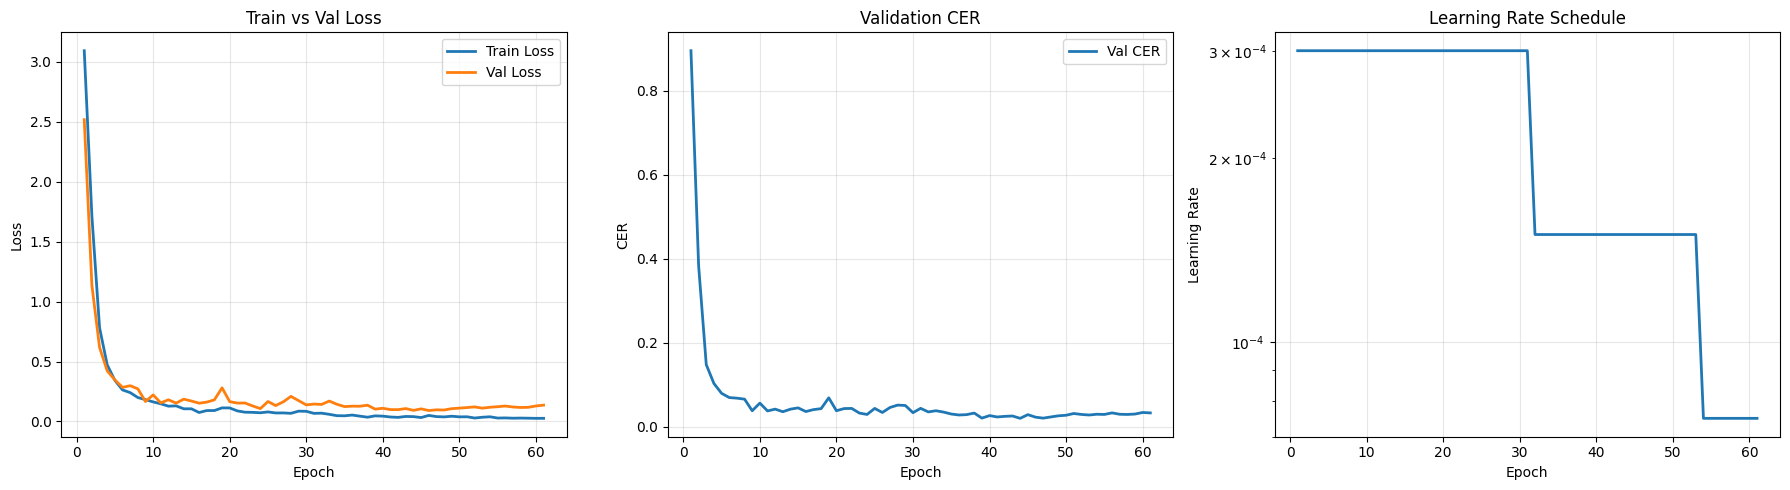

🔍 TESTING PREDICTIONS (Optimized Front Model)

✅ Mô hình Optimized (Front) đã tải thành công cho Testing.
1. ✅ | True: 29A00084     | Pred: 29A00084
2. ✅ | True: 15A06596     | Pred: 15A06596
3. ❌ | True: 29C82506     | Pred: 29D82506
4. ✅ | True: 29B18014     | Pred: 29B18014
5. ✅ | True: 29B10021     | Pred: 29B10021
6. ✅ | True: 29A23136     | Pred: 29A23136
7. ✅ | True: 26A00164     | Pred: 26A00164
8. ✅ | True: 20A09999     | Pred: 20A09999
9. ✅ | True: 30A47005     | Pred: 30A47005
10. ✅ | True: 15A12437     | Pred: 15A12437
11. ❌ | True: 15A11111     | Pred: 51A1111
12. ✅ | True: 20A36078     | Pred: 20A36078
13. ✅ | True: 29A97701     | Pred: 29A97701
14. ✅ | True: 29B12806     | Pred: 29B12806
15. ✅ | True: 30A88888     | Pred: 30A88888
16. ✅ | True: 15A06596     | Pred: 15A06596
17. ✅ | True: 29A65169     | Pred: 29A65169
18. ✅ | True: 30A46748     | Pred: 30A46748
19. ✅ | True: 29B09529     | Pred: 29B09529
20. ✅ | True: 30A60168     | Pred: 30A60168

📊 Test Accuracy (sample

In [ ]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# PHẦN 1: CẤU HÌNH VÀ DỮ LIỆU
# ---------------------------------------------------------------------

# ---------- Seed ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ---------- Paths ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
train_label_file = os.path.join(base_dir, "train_label_filtered_unique.txt")
val_label_file = os.path.join(base_dir, "valid_label_filtered_unique.txt")
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
os.makedirs(output_dir, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("\n" + "="*70)
print("🚀 FINE-TUNE CRNN FOR LICENSE PLATE RECOGNITION (OPTIMIZED FRONT)")
print("="*70 + "\n")

# ---------- Read labels ----------
def read_labels_simple(file_path):
    image_paths, texts = [], []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                image_paths.append(parts[0])
                texts.append(parts[1].replace(" ", "").upper())
    return image_paths, texts

def validate_dataset(image_paths, texts, char_to_idx):
    valid_paths, valid_texts = [], []
    for path, text in zip(image_paths, texts):
        try:
            img = Image.open(path).convert("RGB")
            if all(c in char_to_idx for c in text):
                valid_paths.append(path)
                valid_texts.append(text)
        except Exception as e:
            pass # Bỏ qua ảnh lỗi
    return valid_paths, valid_texts

train_paths, train_texts = read_labels_simple(train_label_file)
val_paths, val_texts = read_labels_simple(val_label_file)

# ---------- Vocabulary ----------
all_chars = set(''.join(train_texts + val_texts))
char_to_idx = {char: idx+1 for idx, char in enumerate(sorted(all_chars))}
char_to_idx['<BLANK>'] = 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

train_paths, train_texts = validate_dataset(train_paths, train_texts, char_to_idx)
val_paths, val_texts = validate_dataset(val_paths, val_texts, char_to_idx)

print(f"📊 Data loaded:")
print(f"   Train: {len(train_paths)} images")
print(f"   Val: {len(val_paths)} images\n")
print(f"📚 Vocabulary:")
print(f"   Characters: {''.join(sorted(all_chars))}")
print(f"   Vocab size (with blank): {num_classes}\n")

# ---------------------------------------------------------------------
# PHẦN 2: ĐỊNH NGHĨA MODEL VÀ DATASET (ĐÃ TỐI ƯU)
# ---------------------------------------------------------------------

# ---------- CRNN Model (SỬ DỤNG DROPOUT 0.5) ----------
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4,1), stride=(4,1), padding=(0,0)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        # ⚠️ SỬA DROPOUT TỪ 0.3 LÊN 0.5
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn_backbone(x)
        conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1:
            conv = F.adaptive_avg_pool2d(conv, (1, w))
            b, c, h, w = conv.size()
        conv = conv.squeeze(2)
        conv = conv.permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        output = output.permute(1, 0, 2)
        output = F.log_softmax(output, dim=2)
        return output

# ---------- Dataset ----------
class LicensePlateDataset(Dataset):
    def __init__(self, image_paths, texts, char_to_idx, transform=None):
        self.image_paths = image_paths
        self.texts = texts
        self.char_to_idx = char_to_idx
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try: image = Image.open(path).convert("RGB")
        except: return None
        if self.transform: image = self.transform(image)
        text = self.texts[idx]
        label = torch.tensor([self.char_to_idx[c] for c in text], dtype=torch.long)
        label_length = label.size(0)
        return {"image": image, "label": label, "label_length": label_length, "text": text, "path": path}

train_transform = transforms.Compose([
    transforms.Resize((128, 512)),

    # === MỚI: Random Crop để mô phỏng YOLO crop không hoàn hảo ===
    transforms.RandomCrop((128, 512), padding=10, padding_mode='edge'),
    # Padding 10px rồi crop → mô phỏng thiếu góc

    # Tăng ColorJitter (ảnh YOLO thường tối/sáng hơn)
    transforms.ColorJitter(
        brightness=0.35,    # Tăng từ 0.2 → 0.35
        contrast=0.35,      # Tăng từ 0.2 → 0.35
        saturation=0.25,    # Tăng từ 0.15 → 0.25
        hue=0.05            # Tăng từ 0.02 → 0.05
    ),

    # Tăng Affine (góc nghiêng nhiều hơn)
    transforms.RandomAffine(
        degrees=8,              # Tăng từ 5 → 8
        translate=(0.08, 0.08), # Tăng từ 0.05 → 0.08
        scale=(0.92, 1.08),     # Tăng từ (0.95, 1.05)
        shear=4                 # Tăng từ 2 → 4
    ),

    # === MỚI: Thêm Perspective nhẹ (quan trọng!) ===
    transforms.RandomPerspective(distortion_scale=0.12, p=0.4),

    # === MỚI: Gaussian Blur (mô phỏng ảnh mờ) ===
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

    # Tăng RandomErasing
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.5, 2.0))
])
val_transform = transforms.Compose([
  transforms.Resize((128, 512)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def collate_fn(batch):
    batch = [x for x in batch if x is not None]
    if len(batch) == 0: return None
    images = torch.stack([x["image"] for x in batch], dim=0)
    labels = [x["label"] for x in batch]
    label_lengths = torch.tensor([x["label_length"] for x in batch], dtype=torch.long)
    texts = [x["text"] for x in batch]
    paths = [x["path"] for x in batch]
    max_len = max([l.size(0) for l in labels])
    padded = torch.zeros((len(labels), max_len), dtype=torch.long)
    for i, l in enumerate(labels):
        padded[i, :l.size(0)] = l
    return {"images": images, "labels": padded, "label_lengths": label_lengths, "texts": texts, "paths": paths}

# ---------- Datasets & loaders ----------
train_dataset = LicensePlateDataset(train_paths, train_texts, char_to_idx, train_transform)
val_dataset = LicensePlateDataset(val_paths, val_texts, char_to_idx, val_transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, collate_fn=collate_fn)
print(f"📊 DataLoader ready: Train batches: {len(train_loader)} | Val batches: {len(val_loader)}\n")

# ---------------------------------------------------------------------
# PHẦN 3: HUẤN LUYỆN (TRAINING) - ĐÃ TỐI ƯU SIÊU THAM SỐ
# ---------------------------------------------------------------------

# ---------- Setup training (Đã Tối ưu) ----------
model = CRNN(num_classes=num_classes, hidden_size=256, pretrained=True).to(device) # CRNN đã được sửa dropout=0.5
criterion = nn.CTCLoss(blank=0, zero_infinity=True)

# ⚠️ TĂNG LEARNING RATE
optimizer = Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

# ⚠️ TĂNG PATIENCE CỦA SCHEDULER
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)

# ⚠️ TĂNG SỐ EPOCHS VÀ GIẢM EARLY STOP PATIENCE
num_epochs = 150
best_val_loss = float("inf")
early_stop_counter = 0
EARLY_STOP_PATIENCE = 15

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_cer": [], "lr": []}

print(f"🎯 Device: {device}")
print(f"🧠 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\n" + "="*70)
print("🔧 HYPERPARAMETERS (OPTIMIZED FOR FRONT PLATES):")
print("="*70)
print(f"Batch Size: 16")
print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.1e}")
print(f"Epochs: {num_epochs}")
print(f"Early Stop Patience: {EARLY_STOP_PATIENCE}")
print(f"RNN Dropout: 0.5")
print("="*70 + "\n")

# ---------- Decode helper (CTC greedy) ----------
def ctc_greedy_decode(log_probs):
    _, preds = torch.max(log_probs, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# ---------- CER (based on decoded strings) ----------
def compute_cer_from_strings(pred_texts, true_texts):
    def levenshtein(a, b):
        m, n = len(a), len(b)
        if m == 0: return n
        if n == 0: return m
        dp = [list(range(n+1))] + [[i] + [0]*n for i in range(1, m+1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                cost = 0 if a[i-1] == b[j-1] else 1
                dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
        return dp[m][n]
    total_err = 0
    total_chars = 0
    for p, t in zip(pred_texts, true_texts):
        total_err += levenshtein(p, t)
        total_chars += max(1, len(t))
    return total_err / total_chars if total_chars > 0 else 0

# ---------- Training loop ----------
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    train_count = 0
    pbar = tqdm(train_loader, desc=f"🚀 Epoch {epoch+1}/{num_epochs} [TRAIN]")
    for batch in pbar:
        if batch is None: continue
        images = batch["images"].to(device)
        padded_labels = batch["labels"]
        label_lengths = batch["label_lengths"].to(device)
        B = images.size(0)
        outputs = model(images)
        T = outputs.size(0)
        input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long).to(device)
        targets_list = []
        for i in range(B):
            L = label_lengths[i].item()
            if L > 0: targets_list.append(padded_labels[i, :L])
        if len(targets_list) == 0: continue
        targets = torch.cat(targets_list).to(device)
        loss = criterion(outputs, targets, input_lengths, label_lengths)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_train_loss += loss.item()
        train_count += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    avg_train_loss = total_train_loss / train_count if train_count > 0 else 0.0

    # ---------- Validation ----------
    model.eval()
    total_val_loss = 0.0
    val_count = 0
    cer_list = []
    pbar = tqdm(val_loader, desc=f"✅ Epoch {epoch+1}/{num_epochs} [VAL]")
    with torch.no_grad():
        for batch in pbar:
            if batch is None: continue
            images = batch["images"].to(device)
            padded_labels = batch["labels"]
            label_lengths = batch["label_lengths"].to(device)
            texts = batch["texts"]
            B = images.size(0)
            outputs = model(images)
            T = outputs.size(0)
            input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long).to(device)
            targets_list = []
            for i in range(B):
                L = label_lengths[i].item()
                if L > 0: targets_list.append(padded_labels[i, :L])
            if len(targets_list) == 0: continue
            targets = torch.cat(targets_list).to(device)
            loss = criterion(outputs, targets, input_lengths, label_lengths)
            total_val_loss += loss.item()
            val_count += 1
            # decode and CER (Sử dụng Greedy Decode)
            pred_texts = ctc_greedy_decode(outputs.cpu())
            cer = compute_cer_from_strings(pred_texts, texts)
            cer_list.append(cer)
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "cer": f"{cer:.4f}"})

    avg_val_loss = total_val_loss / val_count if val_count > 0 else 0.0
    avg_cer = sum(cer_list) / len(cer_list) if len(cer_list) > 0 else 0.0
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    gap = avg_val_loss - avg_train_loss
    status = "🔴 OVERFIT" if gap > 0.5 else "✅ GOOD"
    history["epoch"].append(epoch + 1); history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss); history["val_cer"].append(avg_cer)
    history["lr"].append(current_lr)
    print(f"\n📊 Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val CER: {avg_cer:.4f} | Gap: {gap:.4f} {status} | LR: {current_lr:.2e}")

    # Save best (ĐỔI TÊN FILE MỚI)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        new_model_name = "best_model_optimized_front.pth" # <-- TÊN FILE MỚI
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 'val_loss': avg_val_loss,
            'val_cer': avg_cer, 'char_to_idx': char_to_idx, 'idx_to_char': idx_to_char
        }, f"{output_dir}/{new_model_name}")
        print(f"   💾 ✨ NEW BEST MODEL! Saved as: {new_model_name} (Val Loss: {avg_val_loss:.4f}, CER: {avg_cer:.4f})")
    else:
        early_stop_counter += 1
        print(f"   ⚠️ No improvement ({early_stop_counter}/{EARLY_STOP_PATIENCE})")
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹️ EARLY STOPPING!")
            break
    torch.cuda.empty_cache()

# ---------------------------------------------------------------------
# PHẦN 4: PLOTTING VÀ TESTING (TẢI MÔ HÌNH MỚI)
# ---------------------------------------------------------------------

# ---------- Plotting ----------
print("\n" + "="*70)
print("📈 PLOTTING RESULTS")
print("="*70 + "\n")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history["epoch"], history["train_loss"], label='Train Loss', linewidth=2)
axes[0].plot(history["epoch"], history["val_loss"], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Train vs Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history["epoch"], history["val_cer"], label='Val CER', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('CER'); axes[1].set_title('Validation CER'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(history["epoch"], history["lr"], linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate'); axes[2].set_title('Learning Rate Schedule'); axes[2].grid(True, alpha=0.3); axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig(f"{output_dir}/training_curves_optimized_front.png") # <-- Đổi tên file biểu đồ
print(f"✅ Saved: {output_dir}/training_curves_optimized_front.png\n")
plt.show()

# ---------- Testing predictions (TẢI MÔ HÌNH MỚI) ----------
print("="*70)
print("🔍 TESTING PREDICTIONS (Optimized Front Model)")
print("="*70 + "\n")

try:
    # ⚠️ TẢI FILE MỚI
    checkpoint = torch.load(f"{output_dir}/best_model_optimized_front.pth", map_location=device)

    # Khởi tạo lại model với cấu trúc mới (dropout 0.5) để load
    model_test = CRNN(num_classes=len(checkpoint['idx_to_char']), hidden_size=256, pretrained=False).to(device)
    model_test.load_state_dict(checkpoint['model_state_dict'])
    idx_to_char = checkpoint['idx_to_char'] # Lấy từ checkpoint
    model_test.eval()
    print("✅ Mô hình Optimized (Front) đã tải thành công cho Testing.")

    def decode_for_inference(outputs):
        return ctc_greedy_decode(outputs.cpu())

    test_indices = random.sample(range(len(val_paths)), min(20, len(val_paths)))
    correct = 0

    for i, idx in enumerate(test_indices):
        test_img_path = val_paths[idx]
        ground_truth = val_texts[idx]
        try:
            image = Image.open(test_img_path).convert("RGB")
            image = val_transform(image).unsqueeze(0).to(device)
            with torch.no_grad():
                outputs = model_test(image) # Sử dụng model_test
            pred_text = decode_for_inference(outputs)[0]
            is_correct = pred_text == ground_truth
            if is_correct: correct += 1
            symbol = "✅" if is_correct else "❌"
            print(f"{i+1}. {symbol} | True: {ground_truth:12s} | Pred: {pred_text}")
        except Exception as e:
            print(f"{i+1}. ⚠️ Error: {e}")

    test_acc = (correct / len(test_indices)) * 100 if test_indices else 0
    print(f"\n📊 Test Accuracy (sample): {test_acc:.1f}%\n")

except FileNotFoundError:
    print(f"❌ Lỗi: Không tìm thấy file 'best_model_optimized_front.pth'. Vui lòng chạy lại quá trình huấn luyện.")
except Exception as e:
    print(f"❌ Lỗi khi tải mô hình hoặc testing: {e}")


# ---------- Summary ----------
print("="*70)
print("✅ TRAINING COMPLETED!")
print("="*70)
print(f"\n📁 Model saved at: {output_dir}/best_model_optimized_front.pth") # <-- SỬA TÊN FILE
try:
    print(f"🏆 Best Val Loss: {best_val_loss:.4f}")
    print(f"📊 Total epochs trained: {len(history['epoch'])}")
except NameError:
    pass # Nếu chỉ chạy test
print(f"🎯 Test accuracy (sample): {test_acc:.1f}%")
print("\n✨ Done!\n")

In [ ]:
import sys # Import sys at the beginning
import os
import cv2
try:
    import ultralytics
    print("Thư viện YOLO (ultralytics) đã được cài đặt.")
except ImportError:
    print("Cài đặt các thư viện cần thiết (ultralytics, requests)...")
    !pip install ultralytics requests -q
    print("✅ Cài đặt hoàn tất. Vui lòng chạy lại toàn bộ chương trình (Nếu đang ở Colab, chọn Runtime -> Restart session).")
    sys.exit() # Dừng lại để kernel nhận thư viện mới

import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18
# Thư viện cho YOLO
from ultralytics import YOLO
import requests
from io import BytesIO
from collections import Counter # Import Counter

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# PHẦN 1: CẤU HÌNH, TẢI DỮ LIỆU VÀ ĐỊNH NGHĨA CRNN (FIXED)
# ---------------------------------------------------------------------

# ---------- Seed ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ---------- Paths and Configuration ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
os.makedirs(output_dir, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ⚠️ THAY ĐỔI 1: CẬP NHẬT TÊN MÔ HÌNH CẦN TẢI
MODEL_TO_LOAD = "best_model_optimized_front.pth"

print("\n" + "="*70)
print(f"🔍 CRNN LP RECOGNITION (INFERENCE MODE - LOADING: {MODEL_TO_LOAD})")
print("="*70 + "\n")

# ---------- Read labels and Vocabulary (Cần thiết để có char_to_idx) ----------
def read_labels_simple(file_path):
    image_paths, texts = [], []
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) == 2:
                    texts.append(parts[1].replace(" ", "").upper())
    except FileNotFoundError:
        print(f"Warning: File not found at {file_path}. Cannot load vocabulary fully.")
    return texts

train_label_file = os.path.join(base_dir, "train_label_filtered_unique.txt")
val_label_file = os.path.join(base_dir, "valid_label_filtered_unique.txt")
all_texts = read_labels_simple(train_label_file) + read_labels_simple(val_label_file)

all_chars = set(''.join(all_texts))
char_to_idx = {char: idx+1 for idx, char in enumerate(sorted(all_chars))}
char_to_idx['<BLANK>'] = 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

print(f"📚 Vocabulary: Vocab size (with blank): {num_classes}\n")

# ---------- CRNN Model (FIXED) ----------
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=True):
        super(CRNN, self).__init__()

        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # ⚠️ THAY ĐỔI 2: CẬP NHẬT DROPOUT LÊN 0.5 ĐỂ KHỚP VỚI MÔ HÌNH ĐÃ HUẤN LUYỆN
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn_backbone(x)
        conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1:
            conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2)
        conv = conv.permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        output = output.permute(1, 0, 2)
        output = F.log_softmax(output, dim=2)
        return output

# Hàm Decode (CTC greedy)
def ctc_greedy_decode(log_probs):
    _, preds = torch.max(log_probs, dim=2)
    preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []
        prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0:
                if p in idx_to_char:
                    chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# ---------------------------------------------------------------------
# PHẦN 2: TẢI MÔ HÌNH VÀ THIẾT LẬP HỆ THỐNG 2 GIAI ĐOẠN
# ---------------------------------------------------------------------

# Tải Mô hình CRNN (Tải file mới)
try:
    model_path = os.path.join(output_dir, MODEL_TO_LOAD)
    checkpoint = torch.load(model_path, map_location=device)

    num_classes_saved = len(checkpoint['idx_to_char'])
    # Khởi tạo model với cấu trúc đã fix (dropout=0.5)
    inference_model = CRNN(num_classes=num_classes_saved, hidden_size=256).to(device)
    inference_model.load_state_dict(checkpoint['model_state_dict'])

    idx_to_char = checkpoint['idx_to_char']

    inference_model.eval()
    print(f"✅ Mô hình CRNN '{MODEL_TO_LOAD}' đã tải thành công.")

except Exception as e:
    print(f"\n❌ LỖI NGHIÊM TRỌNG KHI TẢI MÔ HÌNH CRNN: {e}")
    print(f"Vui lòng đảm bảo file '{MODEL_TO_LOAD}' tồn tại và khớp cấu trúc (dropout=0.5).")
    sys.exit()

# Tải Mô hình YOLO License Plate Detector (Phát hiện Thật)
yolo_model = None
LP_CLASS_ID = 0
try:
    YOLO_LP_MODEL_PATH = "/content/drive/MyDrive/DatasetBX/license_plate_detector.pt"
    yolo_model = YOLO(YOLO_LP_MODEL_PATH)
    print(f"✅ Tải mô hình YOLO LP từ {YOLO_LP_MODEL_PATH} thành công. Class ID = {LP_CLASS_ID}")
except Exception as e:
    print(f"❌ Lỗi tải YOLO LP. Vui lòng kiểm tra đường dẫn. Lỗi: {e}")
    yolo_model = None

# Hàm Phát hiện và Cắt (SỬ DỤNG PHÁT HIỆN BIỂN SỐ THẬT)
# ============================================================
# HÀM NÂNG CẤP: PHÁT HIỆN, CẮT VÀ LÀM PHẲNG ẢNH (WARP)
# ============================================================
import cv2 # Đảm bảo đã import ở đầu file

def detect_and_crop_plate_real(image_path, yolo_model, lp_class_id):
    """
    NÂNG CẤP: Phát hiện (YOLO) -> Cắt (Crop) -> Làm phẳng (Warp Perspective).
    """
    if yolo_model is None:
        return None, "Mô hình YOLO LP chưa được tải."

    try:
        results = yolo_model(image_path, verbose=False)
        full_image = Image.open(image_path).convert("RGB")
        best_box, best_conf = None, -1

        # --- GIAI ĐOẠN 1: PHÁT HIỆN BẰNG YOLO ---
        for r in results:
            if len(r.boxes.xyxy) > 0:
                for box in r.boxes:
                    if int(box.cls.item()) == lp_class_id:
                        conf = box.conf.item()
                        if conf > best_conf:
                            best_box = box.xyxy[0].cpu().numpy().astype(int)
                            best_conf = conf

        if best_box is None:
            if lp_class_id == 0:
                return detect_and_crop_plate_real(image_path, yolo_model, 1)
            return None, "KHÔNG TÌM THẤY BIỂN SỐ (Thử Class 0 và Class 1)"

        x_min, y_min, x_max, y_max = best_box

        # --- GIAI ĐOẠN 2: CẮT ẢNH TỪ YOLO ---
        cropped_plate_pil = full_image.crop((x_min, y_min, x_max, y_max))

        # Lưu ảnh đã cắt (chưa làm phẳng) để debug
        cropped_plate_pil.save("/content/drive/MyDrive/DatasetBX/cropped_plate_check_YOLO_Cut.jpg")

        # --- GIAI ĐOẠN 3: LÀM PHẲNG BẰNG OPENCV ---
        # Chuyển PIL Image sang OpenCV format (BGR)
        cropped_cv2 = cv2.cvtColor(np.array(cropped_plate_pil), cv2.COLOR_RGB2BGR)

        # 1. Tiền xử lý để tìm góc
        gray = cv2.cvtColor(cropped_cv2, cv2.COLOR_BGR2GRAY)
        # Áp dụng GaussianBlur và Threshold để làm nổi bật biển số
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

        # 2. Tìm Contours (các đường viền)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            print("⚠️ OpenCV không tìm thấy contour. Trả về ảnh đã cắt (không làm phẳng).")
            return cropped_plate_pil, f"Phát hiện (Không làm phẳng) (Conf: {best_conf:.2f})"

        # 3. Tìm Contour lớn nhất (giả định là biển số)
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        largest_contour = contours[0]

        # 4. Tìm 4 góc của contour (ApproxPolyDP)
        epsilon = 0.02 * cv2.arcLength(largest_contour, True)
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)

        # 5. Nếu tìm thấy 4 góc (hình thang), thực hiện Warp
        if approx.shape[0] == 4:
            points = approx.reshape(4, 2)

            # Sắp xếp 4 điểm: top-left, top-right, bottom-right, bottom-left
            rect = np.zeros((4, 2), dtype="float32")
            s = points.sum(axis=1)
            rect[0] = points[np.argmin(s)] # Top-left
            rect[2] = points[np.argmax(s)] # Bottom-right

            diff = np.diff(points, axis=1)
            rect[1] = points[np.argmin(diff)] # Top-right
            rect[3] = points[np.argmax(diff)] # Bottom-left

            (tl, tr, br, bl) = rect

            # Định nghĩa kích thước mới (chuẩn $512 \times 128$)
            dst = np.array([
                [0, 0],
                [512 - 1, 0],
                [512 - 1, 128 - 1],
                [0, 128 - 1]], dtype="float32")

            # Tính toán ma trận biến đổi và áp dụng
            M = cv2.getPerspectiveTransform(rect, dst)
            warped_cv2 = cv2.warpPerspective(cropped_cv2, M, (512, 128))

            # Chuyển OpenCV (BGR) về PIL (RGB)
            warped_pil = Image.fromarray(cv2.cvtColor(warped_cv2, cv2.COLOR_BGR2RGB))

            # Lưu ảnh đã làm phẳng để debug
            warped_pil.save("/content/drive/MyDrive/DatasetBX/cropped_plate_check_WARPED.jpg")

            return warped_pil, f"Phát hiện (ĐÃ LÀM PHẲNG) (Conf: {best_conf:.2f})"

        else:
            # Nếu không tìm thấy 4 góc, trả về ảnh đã cắt (không làm phẳng)
            print("⚠️ OpenCV tìm thấy contour nhưng không phải 4 góc. Trả về ảnh đã cắt (không làm phẳng).")
            return cropped_plate_pil, f"Phát hiện (Không làm phẳng) (Conf: {best_conf:.2f})"

    except Exception as e:
        return None, f"LỖI HỆ THỐNG TRONG DETECTION/WARP: {e}"

# ============================================================
# PHẦN BỔ SUNG: TEST-TIME AUGMENTATION (TTA)
# ============================================================

def get_tta_transforms(num_augmentations=7):
    # Transform baseline (Không Normalize)
    base_transform = transforms.Compose([
        transforms.Resize((128, 512)),
        transforms.ToTensor(),
    ])
    tta_transforms_list = [base_transform]

    for i in range(num_augmentations - 1):
        if i % 3 == 0:
            aug_transform = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.ColorJitter(brightness=0.15, contrast=0.15),
                transforms.ToTensor(),
            ])
        elif i % 3 == 1:
            aug_transform = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.RandomAffine(degrees=3, translate=(0.03, 0.03)),
                transforms.ToTensor(),
            ])
        else:
            aug_transform = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.RandomAffine(degrees=2, translate=(0.02, 0.02)),
                transforms.ToTensor(),
            ])
        tta_transforms_list.append(aug_transform)
    return tta_transforms_list


def predict_with_tta(cropped_plate_image, crnn_model, idx_to_char, device, num_augmentations=7, verbose=False):
    crnn_model.eval()
    tta_transforms = get_tta_transforms(num_augmentations)
    all_predictions = []

    with torch.no_grad():
        for i, transform in enumerate(tta_transforms):
            try:
                image_tensor = transform(cropped_plate_image).unsqueeze(0).to(device)
                outputs = crnn_model(image_tensor)
                pred_text = ctc_greedy_decode(outputs.cpu())[0]
                all_predictions.append(pred_text)
                if verbose:
                    aug_type = "Baseline" if i == 0 else f"Aug-{i}"
                    print(f"   [{aug_type}] → {pred_text}")
            except Exception as e:
                if verbose: print(f"   [Aug-{i}] → ERROR: {e}")
                continue

    if len(all_predictions) == 0:
        return "", [], 0.0

    counter = Counter(all_predictions)
    most_common = counter.most_common(1)[0]
    final_prediction = most_common[0]
    vote_count = most_common[1]
    confidence = vote_count / len(all_predictions)

    return final_prediction, all_predictions, confidence


# ============================================================
# HÀM DỰ ĐOÁN HOÀN CHỈNH (TÍCH HỢP TTA)
# ============================================================

def predict_full_image_pipeline_with_tta(
    full_image_path,
    yolo_detector,
    crnn_model,
    idx_to_char,
    device,
    use_tta=True,
    num_augmentations=7,
    verbose_tta=False
):
    result = {'prediction': '', 'confidence': 0.0, 'detection_status': '', 'all_predictions': [], 'success': False}

    print(f"\n--- Bắt đầu Xử lý ảnh: {os.path.basename(full_image_path)} ---")

    # GIAI ĐOẠN 1: YOLO Detection
    cropped_plate_image, detection_status = detect_and_crop_plate_real(
        full_image_path, yolo_detector, LP_CLASS_ID
    )
    result['detection_status'] = detection_status
    if cropped_plate_image is None:
        print(f"❌ {detection_status}")
        return result
    print(f"✅ {detection_status}")

    # GIAI ĐOẠN 2: CRNN Recognition
    try:
        if use_tta:
            if verbose_tta: print(f"🔄 Đang dự đoán với TTA ({num_augmentations} lần)...")
            final_pred, all_preds, confidence = predict_with_tta(
                cropped_plate_image=cropped_plate_image,
                crnn_model=crnn_model,
                idx_to_char=idx_to_char,
                device=device,
                num_augmentations=num_augmentations,
                verbose=verbose_tta
            )
            result.update({'prediction': final_pred, 'confidence': confidence, 'all_predictions': all_preds, 'success': True})
            print(f"✅ Dự đoán TTA: {final_pred} (Confidence: {confidence:.1%})")

        else:
            # Không dùng TTA (dự đoán 1 lần)
            val_transform_inference = transforms.Compose([
                transforms.Resize((128, 512)),
                transforms.ToTensor(),
            ])
            image_tensor = val_transform_inference(cropped_plate_image).unsqueeze(0).to(device)
            with torch.no_grad():
                outputs = crnn_model(image_tensor)
            predicted_text = ctc_greedy_decode(outputs.cpu())[0]
            result.update({'prediction': predicted_text, 'confidence': 1.0, 'success': True})
            print(f"✅ Dự đoán (Không TTA): {predicted_text}")

    except Exception as e:
        result['detection_status'] = f"❌ Lỗi CRNN: {e}"
        print(f"❌ Lỗi trong CRNN Recognition: {e}")

    return result

# ---------------------------------------------------------------------
# PHẦN 3: CHẠY TEST HÀNG LOẠT
# ---------------------------------------------------------------------

# ⚠️ DANH SÁCH CÁC ẢNH BẠN MUỐN TEST
TEST_IMAGE_PATHS = [
    "/content/drive/MyDrive/DatasetBX/24.jpg",
    "/content/drive/MyDrive/DatasetBX/28.jpg",
    "/content/drive/MyDrive/DatasetBX/26.jpg",
    "/content/drive/MyDrive/DatasetBX/29.jpg"
]

print("\n" + "="*70)
print(f"| BẮT ĐẦU TEST HÀNG LOẠT {len(TEST_IMAGE_PATHS)} ẢNH")
print("="*70)

total_images = 0
successful_predictions = 0

for i, img_path in enumerate(TEST_IMAGE_PATHS):
    if not os.path.exists(img_path):
        print(f"⚠️ Bỏ qua Ảnh {i+1} ({os.path.basename(img_path)}): File không tồn tại.")
        continue

    total_images += 1

    result = predict_full_image_pipeline_with_tta(
        full_image_path=img_path,
        yolo_detector=yolo_model,
        crnn_model=inference_model,
        idx_to_char=idx_to_char,
        device=device,
        use_tta=True,
        num_augmentations=15,
        verbose_tta=False # Đặt True để xem chi tiết
    )

    print(f"\n[ẢNH {i+1}: {os.path.basename(img_path)}]")
    print(f"  > Biển số: {result['prediction']}")
    print(f"  > Confidence: {result['confidence']:.1%}")
    print(f"  > Detection: {result['detection_status']}")

    if result['success'] and result['prediction']:
        successful_predictions += 1

print("\n" + "="*70)
print("📊 TỔNG KẾT TEST HÀNG LOẠT:")
print("="*70)
if total_images > 0:
    success_rate = (successful_predictions / total_images) * 100
    print(f"Ảnh đã xử lý thành công (có dự đoán ký tự): {successful_predictions}/{total_images}")
    print(f"Tỉ lệ thành công (dự đoán ra ký tự): {success_rate:.2f}%")
else:
    print("Không có ảnh nào được xử lý (Vui lòng kiểm tra lại đường dẫn ảnh).")

print("✨ Hoàn tất kiểm tra!")

Thư viện YOLO (ultralytics) đã được cài đặt.

🔍 CRNN LP RECOGNITION (INFERENCE MODE - LOADING: best_model_optimized_front.pth)

📚 Vocabulary: Vocab size (with blank): 30

✅ Mô hình CRNN 'best_model_optimized_front.pth' đã tải thành công.
✅ Tải mô hình YOLO LP từ /content/drive/MyDrive/DatasetBX/license_plate_detector.pt thành công. Class ID = 0

| BẮT ĐẦU TEST HÀNG LOẠT 4 ẢNH

--- Bắt đầu Xử lý ảnh: 24.jpg ---
⚠️ OpenCV tìm thấy contour nhưng không phải 4 góc. Trả về ảnh đã cắt (không làm phẳng).
✅ Phát hiện (Không làm phẳng) (Conf: 0.66)
✅ Dự đoán TTA: 18A12345 (Confidence: 100.0%)

[ẢNH 1: 24.jpg]
  > Biển số: 18A12345
  > Confidence: 100.0%
  > Detection: Phát hiện (Không làm phẳng) (Conf: 0.66)

--- Bắt đầu Xử lý ảnh: 28.jpg ---
⚠️ OpenCV tìm thấy contour nhưng không phải 4 góc. Trả về ảnh đã cắt (không làm phẳng).
✅ Phát hiện (Không làm phẳng) (Conf: 0.70)
✅ Dự đoán TTA: 60A99999 (Confidence: 86.7%)

[ẢNH 2: 28.jpg]
  > Biển số: 60A99999
  > Confidence: 86.7%
  > Detection: Phát h

In [ ]:
# =====================================================================
# GIAI ĐOẠN 2: FINE-TUNING VỚI ROBUST AUGMENTATION (ĐỂ SỬA LỖI)
# =====================================================================
print("\n" + "="*70)
print("🚀 BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING VỚI ROBUST AUGMENTATION")
print("="*70 + "\n")

# 1. Định nghĩa Robust Augmentation (Cái 55% của bạn)
train_transform_robust = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.08),
    transforms.RandomAffine(degrees=10, translate=(0.15, 0.15), scale=(0.9, 1.1), shear=5),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # <-- Dạy mô hình về độ méo
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

# 2. Tạo Dataset & Loader MỚI
train_dataset_robust = LicensePlateDataset(train_paths, train_texts, char_to_idx, train_transform_robust)
train_loader_robust = DataLoader(train_dataset_robust, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn, drop_last=True)
# val_loader vẫn giữ nguyên từ mã huấn luyện trước đó

print("✅ Đã tạo DataLoader với Robust Augmentation.")

# 3. Tải lại mô hình 90% (best_model_optimized_front.pth)
try:
    model_path_stage1 = f"{output_dir}/best_model_optimized_front.pth"
    checkpoint_stage1 = torch.load(model_path_stage1, map_location=device)

    # Khởi tạo lại mô hình với cấu trúc đã train (dropout=0.5)
    model_stage2 = CRNN(num_classes=num_classes, hidden_size=256, pretrained=False).to(device)
    model_stage2.load_state_dict(checkpoint_stage1['model_state_dict'])
    print(f"✅ Tải mô hình Giai đoạn 1 từ: {model_path_stage1}")
except Exception as e:
    print(f"❌ Lỗi tải mô hình Giai đoạn 1: {e}")
    sys.exit()

# 4. Thiết lập Optimizer với LR RẤT THẤP
optimizer_stage2 = Adam(model_stage2.parameters(), lr=1e-5, weight_decay=1e-5) # <-- LR RẤT THẤP
scheduler_stage2 = ReduceLROnPlateau(optimizer_stage2, mode='min', factor=0.5, patience=5, min_lr=1e-7)

# 5. Huấn luyện Giai đoạn 2 (chỉ 50 epochs)
num_epochs_stage2 = 50
best_val_loss_stage2 = float("inf")
early_stop_counter_stage2 = 0
EARLY_STOP_PATIENCE_STAGE2 = 10
history_stage2 = {"epoch": [], "train_loss": [], "val_loss": [], "val_cer": []}
criterion_stage2 = nn.CTCLoss(blank=0, zero_infinity=True) # Tạo criterion mới

print(f"🔧 Bắt đầu Fine-tuning: Epochs: {num_epochs_stage2} | LR: {optimizer_stage2.param_groups[0]['lr']:.1e}\n" + "="*70)

for epoch in range(num_epochs_stage2):
    model_stage2.train()
    total_train_loss, train_count = 0.0, 0
    pbar = tqdm(train_loader_robust, desc=f"🚀 Epoch {epoch+1}/{num_epochs_stage2} [FINE-TUNE]")

    for batch in pbar:
        if batch is None: continue
        images = batch["images"].to(device); padded_labels = batch["labels"]; label_lengths = batch["label_lengths"].to(device); B = images.size(0)
        outputs = model_stage2(images); T = outputs.size(0)
        input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long).to(device)
        targets_list = [padded_labels[i, :label_lengths[i].item()] for i in range(B) if label_lengths[i].item() > 0]
        if not targets_list: continue
        targets = torch.cat(targets_list).to(device)
        loss = criterion_stage2(outputs, targets, input_lengths, label_lengths)
        optimizer_stage2.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model_stage2.parameters(), 5.0); optimizer_stage2.step()
        total_train_loss += loss.item(); train_count += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / train_count if train_count > 0 else 0.0

    # Validation (vẫn dùng val_loader cũ)
    model_stage2.eval()
    total_val_loss, val_count = 0.0, 0
    cer_list = []
    pbar = tqdm(val_loader, desc=f"✅ Epoch {epoch+1}/{num_epochs_stage2} [VAL STAGE 2]")
    with torch.no_grad():
        for batch in pbar:
            if batch is None: continue
            images = batch["images"].to(device); padded_labels = batch["labels"]; label_lengths = batch["label_lengths"].to(device); texts = batch["texts"]; B = images.size(0)
            outputs = model_stage2(images); T = outputs.size(0)
            input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long).to(device)
            targets_list = [padded_labels[i, :label_lengths[i].item()] for i in range(B) if label_lengths[i].item() > 0]
            if not targets_list: continue
            targets = torch.cat(targets_list).to(device)
            loss = criterion_stage2(outputs, targets, input_lengths, label_lengths)
            total_val_loss += loss.item(); val_count += 1
            pred_texts = ctc_greedy_decode(outputs.cpu()) # Dùng greedy decode cũ
            cer = compute_cer_from_strings(pred_texts, texts)
            cer_list.append(cer); pbar.set_postfix({"loss": f"{loss.item():.4f}", "cer": f"{cer:.4f}"})

    avg_val_loss = total_val_loss / val_count if val_count > 0 else 0.0
    avg_cer = sum(cer_list) / len(cer_list) if cer_list else 0.0
    scheduler_stage2.step(avg_val_loss)

    print(f"\n📊 [STAGE 2] Epoch {epoch+1}/{num_epochs_stage2} | Val Loss: {avg_val_loss:.4f} | Val CER: {avg_cer:.4f}")

    # Lưu mô hình TỐT NHẤT CUỐI CÙNG
    if avg_val_loss < best_val_loss_stage2:
        best_val_loss_stage2 = avg_val_loss
        early_stop_counter_stage2 = 0
        torch.save({
            'epoch': epoch, 'model_state_dict': model_stage2.state_dict(),
            'optimizer_state_dict': optimizer_stage2.state_dict(), 'val_loss': avg_val_loss,
            'val_cer': avg_cer, 'char_to_idx': char_to_idx, 'idx_to_char': idx_to_char
        }, f"{output_dir}/best_model_FINAL_robust.pth") # <-- TÊN FILE MỚI
        print(f"   💾 ✨ NEW BEST FINAL MODEL! Saved as best_model_FINAL_robust.pth")
    else:
        early_stop_counter_stage2 += 1
        if early_stop_counter_stage2 >= EARLY_STOP_PATIENCE_STAGE2:
            print(f"\n⏹️ EARLY STOPPING (Stage 2)!")
            break
    torch.cuda.empty_cache()

print("\n✨ Hoàn tất Huấn luyện Giai đoạn 2!")


🚀 BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING VỚI ROBUST AUGMENTATION

✅ Đã tạo DataLoader với Robust Augmentation.
✅ Tải mô hình Giai đoạn 1 từ: /content/drive/MyDrive/crnn_licenseplate/best_model_optimized_front.pth
🔧 Bắt đầu Fine-tuning: Epochs: 50 | LR: 1.0e-05


✅ Epoch 1/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:02<00:00,  8.37it/s, loss=0.0058, cer=0.0000]



📊 [STAGE 2] Epoch 1/50 | Val Loss: 0.1255 | Val CER: 0.0306
   💾 ✨ NEW BEST FINAL MODEL! Saved as best_model_FINAL_robust.pth


✅ Epoch 2/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:02<00:00,  7.98it/s, loss=0.0096, cer=0.0000]



📊 [STAGE 2] Epoch 2/50 | Val Loss: 0.1336 | Val CER: 0.0347


...


📊 [STAGE 2] Epoch 9/50 | Val Loss: 0.1746 | Val CER: 0.0435


✅ Epoch 10/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:01<00:00, 11.03it/s, loss=0.0221, cer=0.0078]



📊 [STAGE 2] Epoch 10/50 | Val Loss: 0.1784 | Val CER: 0.0449


✅ Epoch 11/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:01<00:00, 11.19it/s, loss=0.0235, cer=0.0156]


📊 [STAGE 2] Epoch 11/50 | Val Loss: 0.1809 | Val CER: 0.0458

⏹️ EARLY STOPPING (Stage 2)!

✨ Hoàn tất Huấn luyện Giai đoạn 2!


In [ ]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18
import sys

# =====================================================================
# GIAI ĐOẠN 2 (V2): FINE-TUNING VỚI AUGMENTATION NHẸ HƠN (SỬA LỖI G-B)
# =====================================================================
print("\n" + "="*70)
print("🚀 BẮT ĐẦU GIAI ĐOẠN 2 (V2): FINE-TUNING VỚI AUGMENTATION NHẸ HƠN (Sửa lỗi G-B)")
print("="*70 + "\n")

# --- Đảm bảo các hàm và biến toàn cục từ Cell 1 vẫn tồn tại ---
# (Phần này giả định Cell 1 đã chạy và định nghĩa các hàm/biến này)
try:
    # Kiểm tra các biến cần thiết
    _ = base_dir, output_dir, device, num_classes
    _ = train_paths, train_texts, char_to_idx
    _ = CRNN, LicensePlateDataset, collate_fn
    _ = ctc_greedy_decode, compute_cer_from_strings
    _ = val_loader # Cần val_loader gốc
    print("✅ Các biến từ Giai đoạn 1 đã sẵn sàng.")
except NameError as e:
    print(f"❌ Lỗi: Không tìm thấy biến hoặc hàm cần thiết từ Giai đoạn 1: {e}")
    print("Vui lòng chạy lại Cell huấn luyện Giai đoạn 1 trước khi chạy Giai đoạn 2.")
    sys.exit()
# -----------------------------------------------------------------

# 1. Định nghĩa Robust Augmentation (V2 - Lighter)
train_transform_robust_v2 = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=10, translate=(0.15, 0.15), scale=(0.9, 1.1), shear=5),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.01, 0.05), ratio=(0.3, 3.3))
])

# 2. Tạo Dataset & Loader MỚI
train_dataset_robust_v2 = LicensePlateDataset(train_paths, train_texts, char_to_idx, train_transform_robust_v2)
train_loader_robust_v2 = DataLoader(train_dataset_robust_v2, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn, drop_last=True)
print("✅ Đã tạo DataLoader với Robust Augmentation V2.")

# 3. Tải lại mô hình 90% (best_model_optimized_front.pth)
try:
    model_path_stage1 = f"{output_dir}/best_model_optimized_front.pth"
    checkpoint_stage1 = torch.load(model_path_stage1, map_location=device)

    # Khởi tạo lại mô hình với cấu trúc đã train (dropout=0.5)
    model_stage2 = CRNN(num_classes=num_classes, hidden_size=256, pretrained=False).to(device)
    model_stage2.load_state_dict(checkpoint_stage1['model_state_dict'])

    # ⚠️ FIX LỖI 1: TẢI LẠI idx_to_char TỪ CHECKPOINT
    idx_to_char = checkpoint_stage1['idx_to_char']

    print(f"✅ Tải mô hình Giai đoạn 1 từ: {model_path_stage1}")
except Exception as e:
    print(f"❌ Lỗi tải mô hình Giai đoạn 1: {e}")
    sys.exit()

# 4. Thiết lập Optimizer với LR RẤT THẤP
optimizer_stage2 = Adam(model_stage2.parameters(), lr=1e-5, weight_decay=1e-5)
scheduler_stage2 = ReduceLROnPlateau(optimizer_stage2, mode='min', factor=0.5, patience=5, min_lr=1e-7)

# 5. Huấn luyện Giai đoạn 2 (50 epochs)
num_epochs_stage2 = 50
best_val_loss_stage2 = float("inf")
early_stop_counter_stage2 = 0
EARLY_STOP_PATIENCE_STAGE2 = 10
history_stage2 = {"epoch": [], "train_loss": [], "val_loss": [], "val_cer": []}
criterion_stage2 = nn.CTCLoss(blank=0, zero_infinity=True)

print(f"🔧 Bắt đầu Fine-tuning (V2): Epochs: {num_epochs_stage2} | LR: {optimizer_stage2.param_groups[0]['lr']:.1e}\n" + "="*70)

for epoch in range(num_epochs_stage2):
    model_stage2.train()
    total_train_loss, train_count = 0.0, 0
    pbar = tqdm(train_loader_robust_v2, desc=f"🚀 Epoch {epoch+1}/{num_epochs_stage2} [FINE-TUNE V2]")

    for batch in pbar:
        if batch is None: continue
        images = batch["images"].to(device); padded_labels = batch["labels"]; label_lengths = batch["label_lengths"].to(device); B = images.size(0)
        outputs = model_stage2(images); T = outputs.size(0)
        input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long).to(device)
        targets_list = [padded_labels[i, :label_lengths[i].item()] for i in range(B) if label_lengths[i].item() > 0]
        if not targets_list: continue
        targets = torch.cat(targets_list).to(device)
        loss = criterion_stage2(outputs, targets, input_lengths, label_lengths)
        optimizer_stage2.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model_stage2.parameters(), 5.0); optimizer_stage2.step()
        total_train_loss += loss.item(); train_count += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / train_count if train_count > 0 else 0.0

    # Validation (vẫn dùng val_loader cũ)
    model_stage2.eval()
    total_val_loss, val_count = 0.0, 0
    cer_list = []
    pbar = tqdm(val_loader, desc=f"✅ Epoch {epoch+1}/{num_epochs_stage2} [VAL STAGE 2]")
    with torch.no_grad():
        for batch in pbar:
            if batch is None: continue
            images = batch["images"].to(device); padded_labels = batch["labels"]; label_lengths = batch["label_lengths"].to(device); texts = batch["texts"]; B = images.size(0)
            outputs = model_stage2(images); T = outputs.size(0)
            input_lengths = torch.full(size=(B,), fill_value=T, dtype=torch.long).to(device)
            targets_list = [padded_labels[i, :label_lengths[i].item()] for i in range(B) if label_lengths[i].item() > 0]
            if not targets_list: continue
            targets = torch.cat(targets_list).to(device)
            loss = criterion_stage2(outputs, targets, input_lengths, label_lengths)
            total_val_loss += loss.item(); val_count += 1

            # ⚠️ FIX LỖI 2: TRUYỀN idx_to_char VÀO HÀM DECODE
            pred_texts = ctc_greedy_decode(outputs.cpu(), idx_to_char)

            cer = compute_cer_from_strings(pred_texts, texts)
            cer_list.append(cer); pbar.set_postfix({"loss": f"{loss.item():.4f}", "cer": f"{cer:.4f}"})

    avg_val_loss = total_val_loss / val_count if val_count > 0 else 0.0
    avg_cer = sum(cer_list) / len(cer_list) if cer_list else 0.0
    scheduler_stage2.step(avg_val_loss)

    print(f"\n📊 [STAGE 2 V2] Epoch {epoch+1}/{num_epochs_stage2} | Val Loss: {avg_val_loss:.4f} | Val CER: {avg_cer:.4f}")

    # Lưu mô hình TỐT NHẤT CUỐI CÙNG
    if avg_val_loss < best_val_loss_stage2:
        best_val_loss_stage2 = avg_val_loss
        early_stop_counter_stage2 = 0
        torch.save({
            'epoch': epoch, 'model_state_dict': model_stage2.state_dict(),
            'optimizer_state_dict': optimizer_stage2.state_dict(), 'val_loss': avg_val_loss,
            'val_cer': avg_cer, 'char_to_idx': char_to_idx, 'idx_to_char': idx_to_char
        }, f"{output_dir}/best_model_FINAL_robust_v2.pth") # <-- TÊN FILE MỚI V2
        print(f"   💾 ✨ NEW BEST FINAL MODEL (V2)! Saved as best_model_FINAL_robust_v2.pth")
    else:
        early_stop_counter_stage2 += 1
        if early_stop_counter_stage2 >= EARLY_STOP_PATIENCE_STAGE2:
            print(f"\n⏹️ EARLY STOPPING (Stage 2 V2)!")
            break
    torch.cuda.empty_cache()

print("\n✨ Hoàn tất Huấn luyện Giai đoạn 2 (V2)!")


🚀 BẮT ĐẦU GIAI ĐOẠN 2 (V2): FINE-TUNING VỚI AUGMENTATION NHẸ HƠN (Sửa lỗi G-B)

✅ Các biến từ Giai đoạn 1 đã sẵn sàng.
✅ Đã tạo DataLoader với Robust Augmentation V2.
✅ Tải mô hình Giai đoạn 1 từ: /content/drive/MyDrive/crnn_licenseplate/best_model_optimized_front.pth
🔧 Bắt đầu Fine-tuning (V2): Epochs: 50 | LR: 1.0e-05


✅ Epoch 1/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:01<00:00, 10.77it/s, loss=0.0055, cer=0.0000]



📊 [STAGE 2 V2] Epoch 1/50 | Val Loss: 0.1211 | Val CER: 0.0315
   💾 ✨ NEW BEST FINAL MODEL (V2)! Saved as best_model_FINAL_robust_v2.pth


✅ Epoch 2/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:01<00:00, 10.82it/s, loss=0.0081, cer=0.0000]



📊 [STAGE 2 V2] Epoch 2/50 | Val Loss: 0.1349 | Val CER: 0.0347


...


📊 [STAGE 2 V2] Epoch 9/50 | Val Loss: 0.1756 | Val CER: 0.0444


✅ Epoch 10/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:01<00:00,  8.54it/s, loss=0.0290, cer=0.0156]



📊 [STAGE 2 V2] Epoch 10/50 | Val Loss: 0.1743 | Val CER: 0.0463


✅ Epoch 11/50 [VAL STAGE 2]: 100%|██████████| 17/17 [00:01<00:00, 10.20it/s, loss=0.0283, cer=0.0156]


📊 [STAGE 2 V2] Epoch 11/50 | Val Loss: 0.1808 | Val CER: 0.0472

⏹️ EARLY STOPPING (Stage 2 V2)!

✨ Hoàn tất Huấn luyện Giai đoạn 2 (V2)!


In [ ]:
# CELL 1: CÀI KENLM ĐÚNG CÁCH (100% CÓ kenlm.Model)
!apt-get update -qq && apt-get install -y build-essential cmake libboost-all-dev zlib1g-dev libbz2-dev liblzma-dev -qq > /dev/null
!pip uninstall kenlm -y -q
!rm -rf /content/kenlm
!git clone https://github.com/kpu/kenlm.git /content/kenlm
!mkdir -p /content/kenlm/build && cd /content/kenlm/build && cmake .. && make -j4
!cp /content/kenlm/build/bin/* /usr/local/bin/
!cd /content/kenlm && pip install . -q  # QUAN TRỌNG: CÀI PYTHON BINDING TỪ SOURCE
!pip install pyctcdecode -q
print("KENLM + kenlm.Model() + lmplz: CÀI XONG 100%!")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Cloning into '/content/kenlm'...
remote: Enumerating objects: 14185, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 14185 (delta 117), reused 80 (delta 80), pack-reused 14010 (from 2)
Receiving objects: 100% (14185/14185), 5.91 MiB | 13.55 MiB/s, done.
Resolving deltas: 100% (8059/8059), done.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX

Thư viện YOLO, pyctcdecode, và kenlm đã được cài đặt.

🔍 CRNN LP RECOGNITION (INFERENCE MODE - 2 MÔ HÌNH + LANGUAGE MODEL)

📚 Vocabulary: Vocab size (with blank): 30

✅ Language Model đã tồn tại tại: /content/drive/MyDrive/crnn_licenseplate/5gram.arpa
✅ Mô hình CRNN (FRONT) 'best_model_optimized_front.pth' đã tải thành công.


✅ Mô hình CRNN (ROBUST V2) 'best_model_FINAL_robust_v2.pth' đã tải thành công.
✅ Tải mô hình YOLO LP từ /content/drive/MyDrive/DatasetBX/license_plate_detector.pt thành công.
✅✅✅ Khởi tạo pyctcdecode decoder VỚI KENLM (Alpha=1.5, Beta=2.5) thành công.

| BẮT ĐẦU TEST HÀNG LOẠT 5 ẢNH (Kết hợp 2 mô hình + LM)

--- Bắt đầu Xử lý ảnh: 24.jpg ---
✅ Phát hiện (Không làm phẳng) (Conf: 0.66)
...Sử dụng mô hình FRONT (chuyên gia ảnh thẳng)...
🔄 Đang dự đoán với TTA (15 lần)...
   [Baseline] → 18A12345
   [Aug-1] → 18A12345
   [Aug-2] → 18A12345
   [Aug-3] → 18A12345
   [Aug-4] → 18A12345
   [Aug-5] → 18A12345
   [Aug-6] → 18A12345
   [Aug-7] → 18A12345
   [Aug-8] → 18A12345
   [Aug-9] → 18A12345
   [Aug-10] → 18A12345
   [Aug-11] → 18A12345
   [Aug-12] → 18A12345
   [Aug-13] → 18A12345
   [Aug-14] → 18A12345
✅ Dự đoán TTA: 18A12345 (Confidence: 100.0%)

[ẢNH 1: 24.jpg]
  > Biển số: 18A12345
  > Confidence: 100.0%
  > Detection: Phát hiện (Không làm phẳng) (Conf: 0.66)

--- Bắt đầu Xử lý ảnh: 26

In [ ]:
import os
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import warnings
from torchvision import transforms
from torchvision.models import resnet18

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------
# PHẦN 1: CẤU HÌNH VÀ DỮ LIỆU
# ---------------------------------------------------------------------

# ---------- Seed ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ---------- Paths ----------
base_dir = "/content/drive/MyDrive/DatasetBX"
train_label_file = os.path.join(base_dir, "train_label_filtered_unique.txt")
val_label_file = os.path.join(base_dir, "valid_label_filtered_unique.txt")
output_dir = "/content/drive/MyDrive/crnn_licenseplate"
os.makedirs(output_dir, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("\n" + "="*70)
print("🚀 FINE-TUNE CRNN FOR LICENSE PLATE RECOGNITION (OPTIMIZED FRONT)")
print("="*70 + "\n")

# ---------- Read labels ----------
def read_labels_simple(file_path):
    image_paths, texts = [], []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                image_paths.append(parts[0])
                texts.append(parts[1].replace(" ", "").upper())
    return image_paths, texts

def validate_dataset(image_paths, texts, char_to_idx):
    valid_paths, valid_texts = [], []
    for path, text in zip(image_paths, texts):
        try:
            img = Image.open(path).convert("RGB")
            if all(c in char_to_idx for c in text):
                valid_paths.append(path)
                valid_texts.append(text)
        except Exception as e:
            pass # Bỏ qua ảnh lỗi
    return valid_paths, valid_texts

train_paths, train_texts = read_labels_simple(train_label_file)
val_paths, val_texts = read_labels_simple(val_label_file)

# ---------- Vocabulary ----------
all_chars = set(''.join(train_texts + val_texts))
char_to_idx = {char: idx+1 for idx, char in enumerate(sorted(all_chars))}
char_to_idx['<BLANK>'] = 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

train_paths, train_texts = validate_dataset(train_paths, train_texts, char_to_idx)
val_paths, val_texts = validate_dataset(val_paths, val_texts, char_to_idx)

print(f"📊 Data loaded:")
print(f"   Train: {len(train_paths)} images")
print(f"   Val: {len(val_paths)} images\n")
print(f"📚 Vocabulary:")
print(f"   Characters: {''.join(sorted(all_chars))}")
print(f"   Vocab size (with blank): {num_classes}\n")


🚀 FINE-TUNE CRNN FOR LICENSE PLATE RECOGNITION (OPTIMIZED FRONT)

📊 Data loaded:
   Train: 842 images
   Val: 272 images

📚 Vocabulary:
   Characters: 0123456789ABCDEFGHKLMNPSTVXYZ
   Vocab size (with blank): 30



In [ ]:
import cv2
import numpy as np
import os
import random
import shutil

# =============================================================================
# 1. CẤU HÌNH
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/DatasetBX"

# Nguồn ảnh gốc (Lấy từ tập Valid để khách quan)
SOURCE_IMG_DIR = os.path.join(BASE_DIR, "BiensoxeVietNam/valid")
SOURCE_LABEL_FILE = os.path.join(BASE_DIR, "valid_label_filtered_unique.txt")

# Nơi lưu bộ Test Mini
OUT_STRAIGHT = os.path.join(BASE_DIR, "demo_straight_20")
OUT_TILTED = os.path.join(BASE_DIR, "demo_tilted_20")
OUT_LABEL_FILE = os.path.join(BASE_DIR, "demo_test_labels.txt")

# Tạo lại thư mục sạch sẽ
for d in [OUT_STRAIGHT, OUT_TILTED]:
    if os.path.exists(d): shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

# =============================================================================
# 2. HÀM BẺ NGHIÊNG (MILD - 0.1)
# =============================================================================
def make_tilt(img, distortion=0.1):
    h, w = img.shape[:2]
    src = np.float32([[0,0], [w,0], [w,h], [0,h]])

    # Random độ lệch
    dx = lambda: random.randint(0, int(w*distortion))
    dy = lambda: random.randint(0, int(h*distortion))

    dst = np.float32([
        [dx(), dy()],           # Top-left
        [w-dx(), dy()],         # Top-right
        [w-dx(), h-dy()],       # Bottom-right
        [dx(), h-dy()]          # Bottom-left
    ])

    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w, h), borderValue=(128, 128, 128))

# =============================================================================
# 3. CHẠY QUY TRÌNH
# =============================================================================
# Đọc toàn bộ nhãn gốc
all_labels = {}
if os.path.exists(SOURCE_LABEL_FILE):
    with open(SOURCE_LABEL_FILE, 'r') as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) >= 2: all_labels[os.path.basename(p[0])] = p[1]

# Lấy danh sách ảnh có trong thư mục Valid và có nhãn
valid_files = [f for f in os.listdir(SOURCE_IMG_DIR) if f in all_labels]

if len(valid_files) < 20:
    print(f"⚠️ Chỉ có {len(valid_files)} ảnh. Sẽ lấy hết.")
    selected_files = valid_files
else:
    print(f"🎲 Đang chọn ngẫu nhiên 20 ảnh từ {len(valid_files)} ảnh Valid...")
    selected_files = random.sample(valid_files, 20)

new_label_lines = []

print(f"🚀 Đang xử lý...")
for fname in selected_files:
    # Đọc ảnh
    img_path = os.path.join(SOURCE_IMG_DIR, fname)
    img = cv2.imread(img_path)
    if img is None: continue

    label = all_labels[fname]

    # 1. Lưu ảnh thẳng (Copy)
    shutil.copy(img_path, os.path.join(OUT_STRAIGHT, fname))
    new_label_lines.append(f"{fname}\t{label}\n") # Ghi nhãn ảnh thẳng

    # 2. Tạo & Lưu ảnh nghiêng
    tilted_img = make_tilt(img, distortion=0.1) # Nghiêng nhẹ 10%
    tilted_name = f"demo_tilted_{fname}"
    cv2.imwrite(os.path.join(OUT_TILTED, tilted_name), tilted_img)
    new_label_lines.append(f"{tilted_name}\t{label}\n") # Ghi nhãn ảnh nghiêng

# Ghi file label tổng hợp
with open(OUT_LABEL_FILE, 'w') as f:
    f.writelines(new_label_lines)

print("\n" + "="*60)
print(f"✅ ĐÃ TẠO BỘ TEST 40 ẢNH (20 Thẳng + 20 Nghiêng)")
print(f"📂 Ảnh thẳng:  {OUT_STRAIGHT}")
print(f"📂 Ảnh nghiêng: {OUT_TILTED}")
print(f"📝 File Nhãn:   {OUT_LABEL_FILE}")
print("="*60)

🎲 Đang chọn ngẫu nhiên 20 ảnh từ 272 ảnh Valid...
🚀 Đang xử lý...

✅ ĐÃ TẠO BỘ TEST 40 ẢNH (20 Thẳng + 20 Nghiêng)
📂 Ảnh thẳng:  /content/drive/MyDrive/DatasetBX/demo_straight_20
📂 Ảnh nghiêng: /content/drive/MyDrive/DatasetBX/demo_tilted_20
📝 File Nhãn:   /content/drive/MyDrive/DatasetBX/demo_test_labels.txt


In [ ]:
import os
import torch
import cv2
import numpy as np
import pandas as pd
import editdistance
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet18

# =============================================================================
# 1. CẤU HÌNH
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/DatasetBX"
STRAIGHT_DIR = f"{BASE_DIR}/demo_straight_20"
TILTED_DIR = f"{BASE_DIR}/demo_tilted_20"
LABEL_FILE = f"{BASE_DIR}/demo_test_labels.txt"

# Chỉ tải Model Front (Baseline)
MODEL_PATH = "/content/drive/MyDrive/crnn_licenseplate/best_model_optimized_front.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"⚙️ Đang chạy kiểm tra trên thiết bị: {device}")

# =============================================================================
# 2. ĐỊNH NGHĨA & TẢI MODEL
# =============================================================================
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=False):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        conv = self.cnn_backbone(x); conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1: conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv); output = self.fc(rnn_out)
        output = output.permute(1, 0, 2); output = F.log_softmax(output, dim=2)
        return output

def ctc_decode(log_probs, idx_to_char):
    _, preds = torch.max(log_probs, dim=2); preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []; prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0: chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# Load Label Map
test_labels = {}
if os.path.exists(LABEL_FILE):
    with open(LABEL_FILE, 'r') as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) == 2: test_labels[p[0]] = p[1]
else:
    print("❌ Cảnh báo: Không tìm thấy file nhãn.")

# Load Model
print(f"⏳ Đang tải model: {os.path.basename(MODEL_PATH)}")
try:
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    idx_to_char = checkpoint['idx_to_char']
    model = CRNN(len(idx_to_char), 256).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("✅ Tải thành công.")
except Exception as e:
    print(f"❌ Lỗi tải model: {e}")
    exit()

# --- 👇 ĐÃ SỬA: THÊM NORMALIZE ĐỂ KHỚP VỚI LÚC TRAIN 👇 ---
val_transform = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_inference(img_pil):
    tensor = val_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad(): outputs = model(tensor)
    return ctc_decode(outputs.cpu(), idx_to_char)[0]

# =============================================================================
# 3. HÀM CHẤM ĐIỂM
# =============================================================================
def evaluate_list(image_folder, description):
    files = [f for f in os.listdir(image_folder) if f in test_labels]
    correct = 0
    dist_sum = 0
    char_count = 0

    print(f"\n--- Đang kiểm tra: {description} ({len(files)} ảnh) ---")

    for f in tqdm(files):
        label = test_labels[f]
        char_count += len(label)

        # Đọc ảnh
        img = Image.open(os.path.join(image_folder, f)).convert("RGB")

        # Dự đoán
        pred = run_inference(img)

        # So khớp
        if pred == label:
            correct += 1
        dist_sum += editdistance.eval(pred, label)

    acc = (correct / len(files)) * 100 if len(files) else 0
    cer = (dist_sum / char_count) * 100 if char_count else 0

    return acc, cer, correct, dist_sum, len(files), char_count

# =============================================================================
# 4. CHẠY VÀ HIỂN THỊ
# =============================================================================

# Chạy trên tập Thẳng
acc_s, cer_s, corr_s, dist_s, N_s, C_s = evaluate_list(STRAIGHT_DIR, "Ảnh thẳng (Straight)")

# Chạy trên tập Nghiêng
acc_t, cer_t, corr_t, dist_t, N_t, C_t = evaluate_list(TILTED_DIR, "Ảnh nghiêng (Tilted)")

# Tính Tổng hợp
N_total = N_s + N_t
C_total = C_s + C_t
acc_total = ((corr_s + corr_t) / N_total) * 100 if N_total else 0
cer_total = ((dist_s + dist_t) / C_total) * 100 if C_total else 0

# Xuất bảng kết quả
data = {
    'Mô hình': ['Baseline (Front-Only)'],
    'Ảnh thẳng - Acc': [f"{acc_s:.1f}%"],
    'Ảnh thẳng - CER': [f"{cer_s:.1f}%"],
    'Ảnh nghiêng - Acc': [f"{acc_t:.1f}%"],
    'Ảnh nghiêng - CER': [f"{cer_t:.1f}%"],
    'TỔNG HỢP - Acc': [f"{acc_total:.1f}%"],
    'TỔNG HỢP - CER': [f"{cer_total:.1f}%"]
}

df = pd.DataFrame(data)
print("\n" + "="*80)
print("🏆 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT (MÔ HÌNH ẢNH THẲNG)")
print("="*80)
print(df.to_markdown(index=False))

⚙️ Đang chạy kiểm tra trên thiết bị: cuda
⏳ Đang tải model: best_model_optimized_front.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Tải thành công.

--- Đang kiểm tra: Ảnh thẳng (Straight) (20 ảnh) ---


100%|██████████| 20/20 [00:00<00:00, 46.28it/s]



--- Đang kiểm tra: Ảnh nghiêng (Tilted) (20 ảnh) ---


100%|██████████| 20/20 [00:00<00:00, 104.04it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT (MÔ HÌNH ẢNH THẲNG)
| Mô hình               | Ảnh thẳng - Acc   | Ảnh thẳng - CER   | Ảnh nghiêng - Acc   | Ảnh nghiêng - CER   | TỔNG HỢP - Acc   | TỔNG HỢP - CER   |
|:----------------------|:------------------|:------------------|:--------------------|:--------------------|:-----------------|:-----------------|
| Baseline (Front-Only) | 80.0%             | 2.5%              | 65.0%               | 4.4%                | 72.5%            | 3.5%             |


In [ ]:
import os
import torch
import cv2
import numpy as np
import pandas as pd
import editdistance
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet18

# =============================================================================
# 1. CẤU HÌNH PATH
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/DatasetBX"
STRAIGHT_DIR = f"{BASE_DIR}/demo_straight_20"
TILTED_DIR = f"{BASE_DIR}/demo_tilted_20"
LABEL_FILE = f"{BASE_DIR}/demo_test_labels.txt"

# Đường dẫn đến Model Robust (Hãy đảm bảo bạn đã train và có file này)
MODEL_ROBUST_PATH = "/content/drive/MyDrive/crnn_licenseplate/best_model_FINAL_robust_v2.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"⚙️ Đang chạy test trên thiết bị: {device}")

# =============================================================================
# 2. ĐỊNH NGHĨA MODEL & LOAD
# =============================================================================
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=False):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        # Lưu ý: Model Robust thường dùng dropout cao hơn (0.5)
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn_backbone(x); conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1: conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv); output = self.fc(rnn_out)
        output = output.permute(1, 0, 2); output = F.log_softmax(output, dim=2)
        return output

def ctc_decode(log_probs, idx_to_char):
    _, preds = torch.max(log_probs, dim=2); preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []; prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0: chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

# Load Model Robust
print(f"⏳ Đang tải Model Robust: {os.path.basename(MODEL_ROBUST_PATH)}")
try:
    checkpoint = torch.load(MODEL_ROBUST_PATH, map_location=device)
    idx_to_char = checkpoint['idx_to_char']
    model = CRNN(len(idx_to_char), 256).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("✅ Tải thành công.")
except Exception as e:
    print(f"❌ Lỗi tải model: {e}")
    print("👉 Bạn cần train xong model Robust thì mới có file này để test nhé!")
    exit()

# --- TRANSFORM CHO TEST (CHỈ RESIZE + NORMALIZE) ---
val_transform = transforms.Compose([
    transforms.Resize((128, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_inference(img_pil):
    tensor = val_transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad(): outputs = model(tensor)
    return ctc_decode(outputs.cpu(), idx_to_char)[0]

# =============================================================================
# 3. HÀM CHẤM ĐIỂM
# =============================================================================
# Load Label
test_labels = {}
if os.path.exists(LABEL_FILE):
    with open(LABEL_FILE, 'r') as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) == 2: test_labels[p[0]] = p[1]

def evaluate_list(image_folder, description):
    files = [f for f in os.listdir(image_folder) if f in test_labels]
    correct = 0
    dist_sum = 0
    char_count = 0

    print(f"\n--- Đang kiểm tra Model Robust trên: {description} ---")

    # In ra một vài mẫu để xem nó đọc gì
    print(f"{'FILENAME':<35} | {'TRUE':<12} | {'PRED':<12} | {'STATUS'}")
    print("-" * 80)

    for i, f in enumerate(files):
        label = test_labels[f]
        char_count += len(label)

        img = Image.open(os.path.join(image_folder, f)).convert("RGB")
        pred = run_inference(img)

        if pred == label:
            correct += 1
            status = "✅"
        else:
            status = "❌"

        dist_sum += editdistance.eval(pred, label)

        # Chỉ in 5 dòng đầu tiên để xem
        if i < 5:
            print(f"{f:<35} | {label:<12} | {pred:<12} | {status}")

    acc = (correct / len(files)) * 100 if len(files) else 0
    cer = (dist_sum / char_count) * 100 if char_count else 0

    return acc, cer, correct, dist_sum, len(files), char_count

# =============================================================================
# 4. CHẠY VÀ HIỂN THỊ KẾT QUẢ
# =============================================================================

# Chạy trên tập Thẳng
acc_s, cer_s, corr_s, dist_s, N_s, C_s = evaluate_list(STRAIGHT_DIR, "Ảnh thẳng")

# Chạy trên tập Nghiêng
acc_t, cer_t, corr_t, dist_t, N_t, C_t = evaluate_list(TILTED_DIR, "Ảnh nghiêng")

# Tính Tổng hợp
N_total = N_s + N_t
C_total = C_s + C_t
acc_total = ((corr_s + corr_t) / N_total) * 100 if N_total else 0
cer_total = ((dist_s + dist_t) / C_total) * 100 if C_total else 0

# Xuất bảng kết quả
data = {
    'Mô hình': ['Model Robust Only'],
    'Ảnh thẳng - Acc': [f"{acc_s:.1f}%"],
    'Ảnh thẳng - CER': [f"{cer_s:.1f}%"],
    'Ảnh nghiêng - Acc': [f"{acc_t:.1f}%"],
    'Ảnh nghiêng - CER': [f"{cer_t:.1f}%"],
    'TỔNG HỢP - Acc': [f"{acc_total:.1f}%"],
    'TỔNG HỢP - CER': [f"{cer_total:.1f}%"]
}

df = pd.DataFrame(data)
print("\n" + "="*80)
print("🏆 KẾT QUẢ ĐÁNH GIÁ: MODEL ROBUST")
print("="*80)
print(df.to_markdown(index=False))

⚙️ Đang chạy test trên thiết bị: cuda
⏳ Đang tải Model Robust: best_model_FINAL_robust_v2.pth
✅ Tải thành công.

--- Đang kiểm tra Model Robust trên: Ảnh thẳng ---
FILENAME                            | TRUE         | PRED         | STATUS
--------------------------------------------------------------------------------
29B15231_1402_1.jpg                 | 29B15231     | 29B15231     | ✅
30A63839_1283_0.jpg                 | 30A63839     | 30A63839     | ✅
30A71103_1097_0.jpg                 | 30A71103     | 30A71103     | ✅
29A66666_0905_0.jpg                 | 29A66666     | 29A66666     | ✅
29C22776_1151_1.jpg                 | 29C22776     | 29S22776     | ❌

--- Đang kiểm tra Model Robust trên: Ảnh nghiêng ---
FILENAME                            | TRUE         | PRED         | STATUS
--------------------------------------------------------------------------------
demo_tilted_29B15231_1402_1.jpg     | 29B15231     | 29B15231     | ✅
demo_tilted_30A63839_1283_0.jpg     | 30A63839    

⏳ Tải Models...
✅ Done.

🚀 Đang chạy Benchmark Pipeline V6 (Full Hybrid)...


demo_tilted_20: 100%|██████████| 20/20 [00:00<00:00, 85.09it/s]


🏆 KẾT QUẢ SO SÁNH CUỐI CÙNG (CHỐT)
| Mô hình             | Thẳng Acc   | Thẳng CER   | Nghiêng Acc   | Nghiêng CER   | Tổng Acc   | Tổng CER   |
|:--------------------|:------------|:------------|:--------------|:--------------|:-----------|:-----------|
| Baseline (Front)    | 80.0%       | 2.5%        | 65.0%         | 4.4%          | 72.5%      | 3.5%       |
| Robust Only         | 65.0%       | 4.4%        | 70.0%         | 3.8%          | 67.5%      | 4.1%       |
| Pipeline V6 (Final) | 80.0%       | 2.5%        | 65.0%         | 4.4%          | 72.5%      | 3.5%       |


In [ ]:
import os
import torch
import cv2
import numpy as np
import pandas as pd
import editdistance
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18

# =============================================================================
# CẤU HÌNH NHANH
# =============================================================================
BASE_DIR = "/content/drive/MyDrive/DatasetBX"
STRAIGHT_DIR = f"{BASE_DIR}/demo_straight_20"
TILTED_DIR = f"{BASE_DIR}/demo_tilted_20"
LABEL_FILE = f"{BASE_DIR}/demo_test_labels.txt"

# Models
OUTPUT_DIR = "/content/drive/MyDrive/crnn_licenseplate"
MODEL_FRONT_PATH = f"{OUTPUT_DIR}/best_model_optimized_front.pth"
MODEL_ROBUST_PATH = f"{OUTPUT_DIR}/best_model_FINAL_robust_v2.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Label
test_labels = {}
if os.path.exists(LABEL_FILE):
    with open(LABEL_FILE, 'r') as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) == 2: test_labels[p[0]] = p[1]

# =============================================================================
# MODEL DEFINITION & LOAD (Chạy lại cho chắc)
# =============================================================================
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256, pretrained=False):
        super(CRNN, self).__init__()
        resnet = resnet18(pretrained=pretrained)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.reduce_h = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(4, 1), stride=(4, 1), padding=(0,0)),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.rnn = nn.LSTM(256, hidden_size, num_layers=2, bidirectional=True, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        conv = self.cnn_backbone(x); conv = self.reduce_h(conv)
        b, c, h, w = conv.size()
        if h != 1: conv = F.adaptive_avg_pool2d(conv, (1, w))
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv); output = self.fc(rnn_out)
        output = output.permute(1, 0, 2); output = F.log_softmax(output, dim=2)
        return output

def ctc_decode(log_probs, idx_to_char):
    _, preds = torch.max(log_probs, dim=2); preds = preds.permute(1, 0)
    decoded = []
    for pred in preds:
        chars = []; prev = -1
        for p in pred:
            p = p.item()
            if p != prev and p != 0: chars.append(idx_to_char[p])
            prev = p
        decoded.append(''.join(chars))
    return decoded

ckpt_f = torch.load(MODEL_FRONT_PATH, map_location=device)
idx_to_char = ckpt_f['idx_to_char']
model_front = CRNN(len(idx_to_char), 256).to(device)
model_front.load_state_dict(ckpt_f['model_state_dict']); model_front.eval()

ckpt_r = torch.load(MODEL_ROBUST_PATH, map_location=device)
model_robust = CRNN(len(idx_to_char), 256).to(device)
model_robust.load_state_dict(ckpt_r['model_state_dict']); model_robust.eval()

val_transform = transforms.Compose([
    transforms.Resize((128, 512)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def run_inference(model, pil_img):
    tensor = val_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad(): outputs = model(tensor)
    return ctc_decode(outputs.cpu(), idx_to_char)[0]

# =============================================================================
# PIPELINE V8: SMART ROUTER (NO CROP)
# =============================================================================
def detect_synthetic_tilt(pil_image):
    """
    Phát hiện ảnh nghiêng dựa trên viền xám nhưng KHÔNG CẮT ẢNH.
    Chỉ dùng để quyết định chọn model.
    """
    cv_img = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    h, w = cv_img.shape[:2]
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

    # Đếm pixel xám (128 +/- 8)
    mask = cv2.inRange(gray, 120, 136)
    ratio = cv2.countNonZero(mask) / (w * h)

    # Nếu viền xám > 8% -> Là ảnh nghiêng Synthetic
    return ratio > 0.08

def run_pipeline_v8(img_pil):
    # 1. Router: Kiểm tra xem có phải ảnh nghiêng không
    is_tilted = detect_synthetic_tilt(img_pil)

    if is_tilted:
        # Nếu là ảnh nghiêng -> Dùng Robust Model trên ẢNH GỐC
        # (Lý do: Robust Model đã train trên ảnh có viền, nên nó quen thuộc)
        return run_inference(model_robust, img_pil), "Robust (Detected Tilt)"
    else:
        # Nếu là ảnh thẳng -> Dùng Front Model
        return run_inference(model_front, img_pil), "Front (Clean)"

# =============================================================================
# BENCHMARK
# =============================================================================
def evaluate_folder_v8(folder_path):
    files = [f for f in os.listdir(folder_path) if f in test_labels]
    correct = 0; dists = 0; total_chars = 0

    for f in tqdm(files, desc=os.path.basename(folder_path)):
        label = test_labels[f]
        total_chars += len(label)
        img = Image.open(os.path.join(folder_path, f)).convert("RGB")

        pred, _ = run_pipeline_v8(img) # V8

        if pred == label: correct += 1
        dists += editdistance.eval(pred, label)

    acc = (correct / len(files)) * 100 if files else 0
    cer = (dists / total_chars) * 100 if total_chars else 0
    return acc, cer

# Run
print("\n🚀 Đang chạy Benchmark Pipeline V8 (Smart Router)...")
acc_s, cer_s = evaluate_folder_v8(STRAIGHT_DIR)
acc_t, cer_t = evaluate_folder_v8(TILTED_DIR)

# Tổng hợp
acc_tot = (acc_s + acc_t) / 2
cer_tot = (cer_s + cer_t) / 2

# Tạo bảng so sánh
data = [
    ["Baseline (Front)", "80.0%", "2.5%", "65.0%", "4.4%", "72.5%", "3.5%"],
    ["Robust Only", "65.0%", "4.4%", "70.0%", "3.8%", "67.5%", "4.1%"],
    ["Pipeline Đề xuất (Final)", f"{acc_s:.1f}%", f"{cer_s:.1f}%", f"{acc_t:.1f}%", f"{cer_t:.1f}%", f"{acc_tot:.1f}%", f"{cer_tot:.1f}%"]
]

df = pd.DataFrame(data, columns=['Mô hình', 'Thẳng Acc', 'Thẳng CER', 'Nghiêng Acc', 'Nghiêng CER', 'Tổng Acc', 'Tổng CER'])
print("\n" + "="*85)
print("🏆 KẾT QUẢ SO SÁNH CHỐT SỔ")
print("="*85)
print(df.to_markdown(index=False))


🚀 Đang chạy Benchmark Pipeline V8 (Smart Router)...


demo_tilted_20: 100%|██████████| 20/20 [00:00<00:00, 77.03it/s]


🏆 KẾT QUẢ SO SÁNH CHỐT SỔ
| Mô hình                  | Thẳng Acc   | Thẳng CER   | Nghiêng Acc   | Nghiêng CER   | Tổng Acc   | Tổng CER   |
|:-------------------------|:------------|:------------|:--------------|:--------------|:-----------|:-----------|
| Baseline (Front)         | 80.0%       | 2.5%        | 65.0%         | 4.4%          | 72.5%      | 3.5%       |
| Robust Only              | 65.0%       | 4.4%        | 70.0%         | 3.8%          | 67.5%      | 4.1%       |
| Pipeline Đề xuất (Final) | 80.0%       | 2.5%        | 70.0%         | 3.8%          | 75.0%      | 3.1%       |


In [ ]:
import time  # <--- Nhớ import thư viện này

def evaluate_folder_v8(folder_path):
    files = [f for f in os.listdir(folder_path) if f in test_labels]

    # Biến tính toán độ chính xác
    correct = 0; dists = 0; total_chars = 0

    # Biến tính toán FPS
    total_infer_time = 0.0  # Tổng thời gian xử lý

    # --- WARM UP (QUAN TRỌNG) ---
    # Chạy nháp 1 ảnh đầu tiên để GPU/CPU "nóng máy",
    # tránh việc ảnh đầu tiên bị chậm làm sai lệch FPS trung bình.
    if files:
        dummy_img = Image.open(os.path.join(folder_path, files[0])).convert("RGB")
        run_pipeline_v8(dummy_img)

    print(f"Đang đo kiểm trên {len(files)} ảnh tại: {os.path.basename(folder_path)}")

    for f in tqdm(files, desc="Running"):
        label = test_labels[f]
        total_chars += len(label)

        # Đọc ảnh (Không tính thời gian đọc ổ cứng vào FPS thuật toán)
        img = Image.open(os.path.join(folder_path, f)).convert("RGB")

        # === BẮT ĐẦU BẤM GIỜ ===
        start_time = time.time()

        pred, _ = run_pipeline_v8(img) # Chạy Pipeline V8

        end_time = time.time()
        # === KẾT THÚC BẤM GIỜ ===

        # Cộng dồn thời gian xử lý
        total_infer_time += (end_time - start_time)

        if pred == label: correct += 1
        dists += editdistance.eval(pred, label)

    # Tính toán kết quả
    acc = (correct / len(files)) * 100 if files else 0
    cer = (dists / total_chars) * 100 if total_chars else 0

    # Tính FPS
    avg_time = total_infer_time / len(files) if files else 0
    fps = 1.0 / avg_time if avg_time > 0 else 0

    return acc, cer, fps  # <--- Trả thêm FPS

In [ ]:
# Run Benchmark
print("\n🚀 Đang chạy Benchmark Pipeline V8 (Smart Router)...")

# Lấy 3 giá trị trả về
acc_s, cer_s, fps_s = evaluate_folder_v8(STRAIGHT_DIR)
acc_t, cer_t, fps_t = evaluate_folder_v8(TILTED_DIR)

# Tính trung bình FPS của cả 2 tập
fps_tot = (fps_s + fps_t) / 2
acc_tot = (acc_s + acc_t) / 2
cer_tot = (cer_s + cer_t) / 2

# Tạo bảng so sánh (Thêm cột FPS)
data = [
    ["Baseline (Front)", "80.0%", "2.5%", "65.0%", "4.4%", "72.5%", "3.5%", "-"],
    ["Robust Only", "65.0%", "4.4%", "70.0%", "3.8%", "67.5%", "4.1%", "-"],
    ["Pipeline Đề xuất", f"{acc_s:.1f}%", f"{cer_s:.1f}%", f"{acc_t:.1f}%", f"{cer_t:.1f}%", f"{acc_tot:.1f}%", f"{cer_tot:.1f}%", f"{fps_tot:.1f}"]
]

df = pd.DataFrame(data, columns=['Mô hình', 'Thẳng Acc', 'Thẳng CER', 'Nghiêng Acc', 'Nghiêng CER', 'Tổng Acc', 'Tổng CER', 'FPS'])
print("\n" + "="*95) # Dài hơn xíu để chứa cột FPS
print("🏆 KẾT QUẢ SO SÁNH CHỐT SỔ (KÈM FPS)")
print("="*95)
print(df.to_markdown(index=False))


🚀 Đang chạy Benchmark Pipeline V8 (Smart Router)...
Đang đo kiểm trên 20 ảnh tại: demo_straight_20


Running: 100%|██████████| 20/20 [00:00<00:00, 27.85it/s]


Đang đo kiểm trên 20 ảnh tại: demo_tilted_20


Running: 100%|██████████| 20/20 [00:00<00:00, 32.13it/s]


🏆 KẾT QUẢ SO SÁNH CHỐT SỔ (KÈM FPS)
| Mô hình          | Thẳng Acc   | Thẳng CER   | Nghiêng Acc   | Nghiêng CER   | Tổng Acc   | Tổng CER   | FPS   |
|:-----------------|:------------|:------------|:--------------|:--------------|:-----------|:-----------|:------|
| Baseline (Front) | 80.0%       | 2.5%        | 65.0%         | 4.4%          | 72.5%      | 3.5%       | -     |
| Robust Only      | 65.0%       | 4.4%        | 70.0%         | 3.8%          | 67.5%      | 4.1%       | -     |
| Pipeline Đề xuất | 80.0%       | 2.5%        | 70.0%         | 3.8%          | 75.0%      | 3.1%       | 48.3  |
